# **Análise Exploratória de Dados: Acidentes em Rodovias Federais (PRF) — 2023, 2024 e 2025**

**Bases utilizadas:** `acidentes2023_todas_causas_tipos`, `acidentes2024_todas_causas_tipos`, `acidentes2025_todas_causas_tipos`

### **Contexto e fonte dos dados**

Os dados foram disponibilizados pela Polícia Rodoviária Federal (PRF) por meio do portal de Dados Abertos, em conformidade com a Lei de Acesso à Informação (Lei nº 12.527/2011) e o Decreto nº 8.777/2016 (Política de Dados Abertos do Executivo Federal). O registro de cada ocorrência é feito no momento do atendimento por meio do **BAT (Boletim de Acidente de Trânsito)**, sistema que reúne informações sobre os envolvidos, o local, os veículos e a dinâmica do acidente — fonte primária da série histórica da PRF, iniciada em 2007.

### **Granularidade dos dados**

As bases `*_todas_causas_tipos` têm a granularidade mais fina que a PRF disponibiliza: **uma linha por combinação de pessoa envolvida (`pesid`), causa e tipo de acidente** dentro de um mesmo acidente (`id`).

Consultando o dicionário oficial de variáveis da PRF para este conjunto específico (seção 1 abaixo): `ilesos`, `feridos_leves`, `feridos_graves` e `mortos` são **indicadores binários (0/1) por pessoa**.

Por isso, este notebook constrói três visões da base, cada uma no nível de granularidade correto para o que está sendo analisado:

| Visão | Nível | Uso |
|---|---|---|
| `df_prf` | 1 linha por pessoa × causa × tipo (bruto) | Nunca usar para contar acidentes, pessoas ou vítimas diretamente |
| `df_pessoas` | 1 linha por pessoa envolvida | Análises de idade, sexo, tipo de envolvido, estado físico |
| `df_ocorrencias` | 1 linha por acidente (`id`), com totais recalculados a partir de `df_pessoas` | Contagem de acidentes, vítimas por acidente, veículos por acidente, comparações entre anos/UF/BR |

### **Objetivo**

Realizar uma EDA que permita:
- Compreender a estrutura, os tipos de variáveis e a qualidade das três bases (com apoio do dicionário oficial);
- Comparar 2023, 2024 e 2025 (em vez de apenas dois anos, como na versão anterior);
- Identificar padrões de causas, tipos, horários, dias da semana e localização;
- Levantar hipóteses e achados que orientem decisões de segurança viária.




## **1. Dicionário de Variáveis (fonte oficial PRF)**

Busquei o dicionário de dados no portal de Dados Abertos da PRF. A página índice (`portal.prf.gov.br/dados-abetos-dicionario-acidentes`) lista dicionários separados por tipo de extração — o que corresponde exatamente às nossas bases é o **"Dicionário de variáveis - acidentes agrupados por pessoa com todas as causas e tipos de acidentes (2017 em diante)"**.

Resumo (com minhas próprias palavras, a partir da definição oficial de cada campo) das variáveis desse conjunto:

| # | Variável | Descrição |
|---|---|---|
| 1 | `id` | Identificador numérico do acidente |
| 2 | `pesid` | Identificador numérico da pessoa envolvida |
| 3 | `data_inversa` | Data da ocorrência (`dd/mm/aaaa`) |
| 4 | `dia_semana` | Dia da semana da ocorrência |
| 5 | `horario` | Horário da ocorrência (`hh:mm:ss`) |
| 6 | `uf` | Unidade da Federação (ex.: MG, PE, DF) |
| 7 | `br` | Identificador numérico da rodovia federal (BR) |
| 8 | `km` | Quilômetro da ocorrência (mínimo 0,1 km, decimal com ponto) |
| 9 | `municipio` | Município onde o acidente ocorreu |
| 10 | `causa_principal` | Indica se essa causa foi apontada como principal pelo policial |
| 11 | `causa_acidente` | Causa presumível, com base em vestígios e indícios do local |
| 12 | `ordem_tipo_acidente` | Ordem da sequência de eventos do acidente |
| 13 | `tipo_acidente` | Tipo do acidente (ex.: colisão frontal, saída de pista) |
| 14 | `classificacao_acidente` | Gravidade: Sem Vítimas, Com Vítimas Feridas, Com Vítimas Fatais, Ignorado |
| 15 | `fase_dia` | Fase do dia no momento do acidente (amanhecer, pleno dia, etc.) |
| 16 | `sentido_via` | Sentido da via no ponto de colisão (crescente/decrescente) |
| 17 | `condicao_metereologica` | Condição meteorológica no momento do acidente |
| 18 | `tipo_pista` | Tipo de pista (simples, dupla ou múltipla) |
| 19 | `tracado_via` | Traçado da via |
| 20 | `uso_solo` | Urbano (Sim) ou Rural (Não) |
| 21 | `id_veiculo` | Identificador numérico do veículo envolvido |
| 22 | `tipo_veiculo` | Tipo do veículo (Art. 96 do CTB): automóvel, caminhão, moto, etc. |
| 23 | `marca` | Marca/modelo do veículo |
| 24 | `ano_fabricacao_veiculo` | Ano de fabricação do veículo |
| 25 | `tipo_envolvido` | Papel da pessoa no acidente (condutor, passageiro, pedestre, etc.) |
| 26 | `estado_fisico` | Estado da pessoa (morto, ferido leve, ferido grave, ileso, ignorado) |
| 27 | `idade` | Idade do envolvido (`-1` = não coletada) |
| 28 | `sexo` | Sexo do envolvido (`inválido` = não coletado) |
| 29 | `ilesos` | **Flag binária (0/1)** — essa pessoa ficou ilesa? |
| 30 | `feridos_leves` | **Flag binária (0/1)** — essa pessoa teve ferimento leve? |
| 31 | `feridos_graves` | **Flag binária (0/1)** — essa pessoa teve ferimento grave? |
| 32 | `mortos` | **Flag binária (0/1)** — essa pessoa morreu? |
| 33 | `latitude` | Latitude do acidente (formato geodésico decimal) |
| 34 | `longitude` | Longitude do acidente (formato geodésico decimal) |
| 35 | `regional` | Superintendência regional da PRF responsável |
| 36 | `delegacia` | Delegacia da PRF responsável |
| 37 | `uop` | Unidade Operacional da PRF responsável |

**Fonte:** Dicionário de variáveis — Acidentes agrupados por pessoa, com todas as causas e tipos de acidentes (registros a partir de janeiro de 2017), Polícia Rodoviária Federal, Brasília, set. 2017. Índice: https://portal.prf.gov.br/dados-abetos-dicionario-acidentes

⚠️ Os nomes de coluna acima seguem a grafia do dicionário oficial (com acentos em alguns termos); nos arquivos CSV reais, os cabeçalhos costumam vir sem acentuação (`snake_case` puro, ex.: `classificacao_acidente`, `condicao_metereologica`). A célula de checagem logo abaixo da carga dos dados confirma automaticamente se os nomes batem com o esperado.


## **2. Preparando o ambiente**

### **2.0 Configurações globais, paleta de cores e funções auxiliares**

Esta célula concentra tudo que é reaproveitado em mais de um lugar do notebook:
constantes (cores oficiais, ordem dos dias, faixas etárias), e as funções. Rodar esta célula uma
única vez, logo após os imports, é o que permite que todo o resto do notebook
só chame `nome_da_funcao(...)` em vez de repetir código.


In [ ]:
# --- Bibliotecas principais -------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 100

# Bibliotecas de uso pontual (mapas e feriados), instaladas sob demanda para
# não pesar o ambiente quando o notebook é executado só até certa seção.
try:
    import geobr
except ImportError:
    !pip install geobr -q
    import geobr

try:
    import geopandas as gpd
except ImportError:
    !pip install geopandas -q
    import geopandas as gpd

try:
    import holidays
except ImportError:
    !pip install holidays -q
    import holidays

print('Ambiente pronto.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 23.2 MB/s eta 0:00:00
Ambiente pronto.


In [ ]:
# --- Paleta de cores institucional (PRF) ------------------------------------
# Definida uma única vez e reaproveitada em todos os gráficos do notebook,
CORES_PRF = {
    'azul_marinho': '#002855',    # cor primária: barras padrão, títulos, textos de destaque
    'dourado_destaque': '#D97706',  # destaque de UMA categoria crítica em rankings
    'amarelo_ouro': '#E6A100',    # tom intermediário em gradientes e comparação entre anos
    'amarelo_claro': '#FFC72C',   # bordas/realces pontuais
    'creme': '#FFF9E6',           # tom inicial dos gradientes sequenciais
    'cinza_neutro': '#7A8D9B',    # categorias "não destacadas" em rankings com 3+ níveis
    'cinza_texto': '#1E293B',     # cor de rótulos e eixos
    'cinza_comparativo': '#8A9EA7',  # série "mais antiga" em comparações por ano
}

# Atalhos usados com muita frequência (evita repetir CORES_PRF['...'] toda hora)
AZUL_PRF = CORES_PRF['azul_marinho']
DOURADO_DESTAQUE = CORES_PRF['dourado_destaque']

# Colormap sequencial padrão PRF: creme -> dourado -> azul marinho.
# Usado em heatmaps, mapas coropléticos e tabelas com gradiente de cor.
CMAP_PRF_SEQUENCIAL = sns.blend_palette(
    [CORES_PRF['creme'], CORES_PRF['amarelo_ouro'], CORES_PRF['azul_marinho']],
    as_cmap=True,
)

# Variante com 5 tons para heatmaps de "hotspot", onde o objetivo é destacar
# só os pontos extremos (mais contraste no topo da escala que o sequencial acima).
CMAP_PRF_HOTSPOT = mcolors.LinearSegmentedColormap.from_list(
    'PRF_Hotspot',
    ['#FAFAFA', '#FFE58F', CORES_PRF['dourado_destaque'], CORES_PRF['azul_marinho'], '#001026'],
)

# Cor fixa por ano-base, usada em toda comparação 2023 x 2024 x 2025
CORES_PRF_ANOS = {
    2023: CORES_PRF['cinza_comparativo'],
    2024: CORES_PRF['amarelo_ouro'],
    2025: CORES_PRF['azul_marinho'],
}


In [ ]:
# --- Constantes de domínio (PRF) --------------------------------------------
MESES = {
    1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 5: 'Maio', 6: 'Junho',
    7: 'Julho', 8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro',
}

ORDEM_DIAS = [
    'segunda-feira', 'terça-feira', 'quarta-feira', 'quinta-feira',
    'sexta-feira', 'sábado', 'domingo',
]

BINS_IDADE = [0, 18, 25, 35, 45, 60, 200]
LABELS_IDADE = ['Até 17', '18-24', '25-34', '35-44', '45-59', '60+']

# Colunas que nunca fazem sentido em boxplot/histograma (identificadores e coordenadas)
COLUNAS_ID = ('id', 'ano_base')

CAMINHO_BASE = '/content/drive/MyDrive/Bases_PRF/'


In [ ]:
# --- Funções auxiliares ------------------------------------------------------

def formatar_numero_ptbr(valor, casas=0, sufixo=''):
    """Formata um número no padrão pt-BR (ponto de milhar, vírgula decimal)."""
    texto = f'{valor:,.{casas}f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    return f'{texto}{sufixo}'


def exportar_csv(dataframe, nome_arquivo, caminho_base=CAMINHO_BASE):
    """Exporta um DataFrame para CSV dentro de `caminho_base` e confirma no console."""
    caminho_saida = caminho_base + nome_arquivo
    dataframe.to_csv(caminho_saida, index=False, encoding='utf-8')
    print(f'Arquivo exportado com sucesso para: {caminho_saida}')


def inspecionar_base_individual(caminho: str, ano: int) -> pd.DataFrame:
    """Carrega e exibe um relatório de inspeção (formato, tipos, nulos) para um ano da PRF."""
    print('=' * 70)
    print(f' INSPECIONANDO A BASE DE {ano}')
    print('=' * 70)

    # Tentativa de leitura robusta cobrindo diferentes separadores e encodings
    tentativas = [
        {'sep': ';', 'encoding': 'latin1'},
        {'sep': ';', 'encoding': 'utf-8'},
        {'sep': ',', 'encoding': 'utf-8'},
        {'sep': ',', 'encoding': 'latin1'},
    ]

    df = None
    for opcoes in tentativas:
        try:
            temp_df = pd.read_csv(caminho, **opcoes, low_memory=False)
            if temp_df.shape[1] > 1:
                df = temp_df
                print(f'Sucesso ao ler com separador "{opcoes["sep"]}" e encoding "{opcoes["encoding"]}".')
                break
        except Exception:
            continue

    if df is None:
        print(f'Erro crítico: Não foi possível ler o arquivo de {ano}. Verifique o caminho.')
        return None

    df.columns = df.columns.str.strip().str.lower()

    print(f'Dimensões: {df.shape[0]:,} linhas x {df.shape[1]} colunas'.replace(',', '.'))
    print('Tipos de dados (resumo):')
    print(df.dtypes.value_counts())

    print('\n Verificando colunas-chave (tipos e valores nulos):')
    colunas_chave = [
        'id', 'pesid', 'data_inversa', 'horario', 'classificacao_acidente',
        'marca', 'id_veiculo', 'mortos', 'feridos_graves', 'feridos_leves',
    ]
    for col in colunas_chave:
        if col in df.columns:
            nulos = df[col].isna().sum()
            dtype = df[col].dtype
            print(f'   - {col:25s} | dtype: {str(dtype):10s} | nulos: {nulos:,} ({nulos/len(df)*100:.2f}%)'.replace(',', '.'))
        else:
            print(f'   - {col:25s} | ATENÇÃO: Coluna ausente neste ano!')

    print('\n')
    return df


def definir_turno(hora: int) -> str:
    """Classifica uma hora do dia (0-23) em um turno."""
    if 6 <= hora < 12:
        return 'Manhã'
    if 12 <= hora < 18:
        return 'Tarde'
    if 18 <= hora < 24:
        return 'Noite'
    return 'Madrugada'


def gerar_metadados(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Gera um relatório de metadados (tipo, nulos, cardinalidade) para um DataFrame."""
    metadata = pd.DataFrame({
        'nome_variavel': dataframe.columns,
        'tipo': dataframe.dtypes.astype(str).values,
        'qtd_nulos': dataframe.isnull().sum().values,
        'percent_nulos': (dataframe.isnull().sum().values / len(dataframe) * 100).round(2),
        'cardinalidade': dataframe.nunique().values,
    })
    return metadata.sort_values('tipo').reset_index(drop=True)


def box_plot(dataframe: pd.DataFrame, excluir=COLUNAS_ID + ('latitude', 'longitude')):
    """Plota boxplots para as variáveis numéricas do DataFrame, 3 por linha."""
    colunas_numericas = [
        c for c in dataframe.select_dtypes(include=[np.number]).columns if c not in excluir
    ]
    nrows = -(-len(colunas_numericas) // 3)
    fig, axes = plt.subplots(nrows=nrows, ncols=3, figsize=(18, nrows * 5))
    axes = np.ravel(axes)

    for i, coluna in enumerate(colunas_numericas):
        sns.boxplot(data=dataframe[coluna], ax=axes[i], color='skyblue', fliersize=3)
        axes[i].set_title(coluna, fontdict={'fontsize': 13, 'fontweight': 'bold'})

    for j in range(len(colunas_numericas), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle('Distribuição de Dados — Boxplot', fontweight='bold', fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()


def relatorio_outliers(df: pd.DataFrame, excluir=COLUNAS_ID + ('latitude', 'longitude')) -> pd.DataFrame:
    """Gera um relatório de outliers (método IQR) para as colunas numéricas de um DataFrame."""
    colunas_numericas = [c for c in df.select_dtypes(include=[np.number]).columns if c not in excluir]
    relatorio = []

    for coluna in colunas_numericas:
        serie = df[coluna].dropna()
        if serie.empty:
            continue
        q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
        iqr = q3 - q1
        limite_inferior, limite_superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]
        relatorio.append({
            'coluna': coluna,
            'qtd_total': len(serie),
            'qtd_outliers': len(outliers),
            'percent_outliers': round(len(outliers) / len(serie) * 100, 2),
            'limite_inferior': round(limite_inferior, 2),
            'limite_superior': round(limite_superior, 2),
        })

    return pd.DataFrame(relatorio).sort_values('percent_outliers', ascending=False).reset_index(drop=True)


def frequencia_categorica(df: pd.DataFrame, corte_cardinalidade=30, graficos_por_linha=2):
    """Plota a frequência das categorias de variáveis categóricas de baixa cardinalidade."""
    candidatas = [
        c for c in df.select_dtypes(include='object').columns
        if df[c].nunique() <= corte_cardinalidade
    ]

    nlinhas = -(-len(candidatas) // graficos_por_linha)
    fig, axs = plt.subplots(nrows=nlinhas, ncols=graficos_por_linha, figsize=(15, 5 * nlinhas))
    axs = np.ravel(axs)

    for i, coluna in enumerate(candidatas):
        df[coluna].value_counts().sort_index().plot(
            kind='barh', ax=axs[i], color='royalblue', edgecolor='black', alpha=0.8
        )
        axs[i].set_title(f'Frequência em {coluna}')

    for j in range(len(candidatas), len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()


def ranking_gravidade(df, coluna, minimo=20, top=15):
    """Ranking de % de acidentes graves/fatais por categoria, com piso mínimo de registros."""
    return (
        df
        .groupby(coluna)
        .agg(total_acidentes=('id', 'count'), graves_fatais=('grave_ou_fatal', 'sum'))
        .assign(proporcao_graves_fatais=lambda d: round(d['graves_fatais'] / d['total_acidentes'] * 100, 2))
        .query(f'total_acidentes >= {minimo}')
        .sort_values('proporcao_graves_fatais', ascending=False)
        .head(top)
    )


def plot_barh_destaque(
    dados, coluna_categoria, coluna_valor, titulo,
    cores=None, destacar=None, cor_base=AZUL_PRF, cor_destaque=DOURADO_DESTAQUE,
    rotulos=None, casas_rotulo=0, sufixo_rotulo='', xlim_factor=1.18,
    figsize=(10, 6), edgecolor=None, linewidth=0,
):
    """
    Gráfico de barras horizontais no estilo PRF: eixo de valor oculto, bordas
    removidas e rótulo de valor direto na ponta da barra
    """
    if cores is None:
        alvo = set(destacar) if destacar else set()
        cores = [cor_destaque if v in alvo else cor_base for v in dados[coluna_categoria]]

    if rotulos is None:
        rotulos = [formatar_numero_ptbr(v, casas_rotulo, sufixo_rotulo) for v in dados[coluna_valor]]

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(
        dados[coluna_categoria], dados[coluna_valor],
        color=cores, height=0.65, edgecolor=edgecolor, linewidth=linewidth,
    )
    ax.bar_label(bars, labels=rotulos, padding=6, fontweight='bold', color=cor_base, fontsize=10)

    ax.xaxis.set_ticks([])
    ax.tick_params(axis='y', length=0, labelsize=11, labelcolor=CORES_PRF['cinza_texto'])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlim(0, dados[coluna_valor].max() * xlim_factor)

    ax.set_title(titulo, fontsize=14, fontweight='bold', color=cor_base, pad=20, loc='left')
    plt.tight_layout()
    plt.show()
    return fig, ax


### **2.1 Carregando as três bases**

Duas formas de trazer os arquivos para o Colab — use a que fizer sentido para você:

- **Google Drive** (recomendado para os três arquivos, que tendem a ser grandes): monte o Drive e aponte o caminho da pasta.
- **Upload direto**: descomente a célula com `files.upload()`.

In [ ]:
from src.data_loader import load_data

# Carrega os dados usando os IDs padrão definidos no data_loader
df = load_data()


In [ ]:
"""from google.colab import drive
drive.mount('/content/drive')

# Ajuste este caminho para a pasta onde estão os 3 CSVs no seu Drive
CAMINHO_BASE = '/content/drive/MyDrive/Bases_PRF/'

ARQUIVOS = {
    2023: CAMINHO_BASE + 'acidentes2023_todas_causas_tipos.csv',
    2024: CAMINHO_BASE + 'acidentes2024_todas_causas_tipos.csv',
    2025: CAMINHO_BASE + 'acidentes2025_todas_causas_tipos.csv',
}"""


Mounted at /content/drive


In [ ]:
# Configuração de caminhos (ajuste conforme o seu ambiente no Google Drive)
ARQUIVOS = {
    2023: CAMINHO_BASE + 'acidentes2023_todas_causas_tipos.csv',
    2024: CAMINHO_BASE + 'acidentes2024_todas_causas_tipos.csv',
    2025: CAMINHO_BASE + 'acidentes2025_todas_causas_tipos.csv',
}

bases_individuais = {}
for ano, caminho in ARQUIVOS.items():
    bases_individuais[ano] = inspecionar_base_individual(caminho, ano)


 INSPECIONANDO A BASE DE 2023
Sucesso ao ler com separador ";" e encoding "latin1".
Dimensões: 571.052 linhas x 37 colunas
Tipos de dados (resumo):
object     26
float64     9
int64       2
Name: count, dtype: int64

 Verificando colunas-chave (tipos e valores nulos):
   - id                        | dtype: int64      | nulos: 0 (0.00%)
   - pesid                     | dtype: float64    | nulos: 55.887 (9.79%)
   - data_inversa              | dtype: object     | nulos: 0 (0.00%)
   - horario                   | dtype: object     | nulos: 0 (0.00%)
   - classificacao_acidente    | dtype: object     | nulos: 3 (0.00%)
   - marca                     | dtype: object     | nulos: 0 (0.00%)
   - id_veiculo                | dtype: float64    | nulos: 20.772 (3.64%)
   - mortos                    | dtype: float64    | nulos: 55.887 (9.79%)
   - feridos_graves            | dtype: float64    | nulos: 55.887 (9.79%)
   - feridos_leves             | dtype: float64    | nulos: 55.887 (9.79%)


 INS

In [ ]:
dfs_tratados = {}

for ano in ARQUIVOS:
    print(f'Processando base de {ano}...')

    df = bases_individuais[ano].copy()
    df['ano_base'] = ano

    # Correção preventiva de tipos críticos por base individual
    if 'id' in df.columns:
        df['id'] = pd.to_numeric(df['id'], errors='coerce').astype('Int64')

    if 'pesid' in df.columns:
        df['pesid'] = pd.to_numeric(df['pesid'], errors='coerce').astype('Int64')

    if 'id_veiculo' in df.columns:
        df['id_veiculo'] = pd.to_numeric(df['id_veiculo'], errors='coerce').astype('Int64')

    dfs_tratados[ano] = df


df_prf = pd.concat(dfs_tratados.values(), ignore_index=True)

print(f'\nConsolidação final bem-sucedida!')
print(f'Total de linhas: {df_prf.shape[0]:,} | Total de colunas: {df_prf.shape[1]}'.replace(',', '.'))
print(f'Tipo atual da coluna id no consolidado: {df_prf["id"].dtype}')

Processando base de 2023...
Processando base de 2024...
Processando base de 2025...

Consolidação final bem-sucedida!
Total de linhas: 1.758.277 | Total de colunas: 38
Tipo atual da coluna id no consolidado: Int64


In [ ]:
# Conferindo as colunas reais contra o dicionário oficial (seção 1)
colunas_esperadas = {
    'id', 'pesid', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio',
    'causa_principal', 'causa_acidente', 'ordem_tipo_acidente', 'tipo_acidente',
    'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica',
    'tipo_pista', 'tracado_via', 'uso_solo', 'id_veiculo', 'tipo_veiculo', 'marca',
    'ano_fabricacao_veiculo', 'tipo_envolvido', 'estado_fisico', 'idade', 'sexo',
    'ilesos', 'feridos_leves', 'feridos_graves', 'mortos', 'latitude', 'longitude',
    'regional', 'delegacia', 'uop',
}
colunas_reais = set(df_prf.columns) - {'ano_base'}

faltando = colunas_esperadas - colunas_reais
extras = colunas_reais - colunas_esperadas

print('Colunas do dicionário ausentes nos dados:', faltando or 'nenhuma')
print('Colunas nos dados que não estão no dicionário:', extras or 'nenhuma')


Colunas do dicionário ausentes nos dados: nenhuma
Colunas nos dados que não estão no dicionário: nenhuma


## **3. Exploração Inicial dos Dados**

In [ ]:
df_prf.head()

,id,pesid,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_principal,causa_acidente,ordem_tipo_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,id_veiculo,tipo_veiculo,marca,ano_fabricacao_veiculo,tipo_envolvido,estado_fisico,idade,sexo,ilesos,feridos_leves,feridos_graves,mortos,latitude,longitude,regional,delegacia,uop,ano_base
0,496506,1082142,2023-01-01,domingo,00:15:00,MG,116.0,587,MANHUACU,Não,Reação tardia ou ineficiente do condutor,2,Queda de ocupante de veículo,Com Vítimas Feridas,Plena Noite,Crescente,Nublado,Simples,Reta,Sim,872937,Motocicleta,HONDA/CB 250F TWISTER,2018.0,Condutor,Lesões Leves,24.0,Masculino,0.0,1.0,0.0,0.0,"-20,24173903","-42,15868042",SPRF-MG,DEL06-MG,UOP03-DEL06-MG,2023
1,496506,1082142,2023-01-01,domingo,00:15:00,MG,116.0,587,MANHUACU,Sim,Ingestão de álcool pelo condutor,2,Queda de ocupante de veículo,Com Vítimas Feridas,Plena Noite,Crescente,Nublado,Simples,Reta,Sim,872937,Motocicleta,HONDA/CB 250F TWISTER,2018.0,Condutor,Lesões Leves,24.0,Masculino,0.0,1.0,0.0,0.0,"-20,24173903","-42,15868042",SPRF-MG,DEL06-MG,UOP03-DEL06-MG,2023
2,496506,1082142,2023-01-01,domingo,00:15:00,MG,116.0,587,MANHUACU,Não,Reação tardia ou ineficiente do condutor,1,Tombamento,Com Vítimas Feridas,Plena Noite,Crescente,Nublado,Simples,Reta,Sim,872937,Motocicleta,HONDA/CB 250F TWISTER,2018.0,Condutor,Lesões Leves,24.0,Masculino,0.0,1.0,0.0,0.0,"-20,24173903","-42,15868042",SPRF-MG,DEL06-MG,UOP03-DEL06-MG,2023
3,496506,1082142,2023-01-01,domingo,00:15:00,MG,116.0,587,MANHUACU,Sim,Ingestão de álcool pelo condutor,1,Tombamento,Com Vítimas Feridas,Plena Noite,Crescente,Nublado,Simples,Reta,Sim,872937,Motocicleta,HONDA/CB 250F TWISTER,2018.0,Condutor,Lesões Leves,24.0,Masculino,0.0,1.0,0.0,0.0,"-20,24173903","-42,15868042",SPRF-MG,DEL06-MG,UOP03-DEL06-MG,2023
4,496507,1082138,2023-01-01,domingo,00:20:00,MG,381.0,"686,5",LAVRAS,Sim,Demais falhas mecânicas ou elétricas,1,Capotamento,Com Vítimas Feridas,Pleno dia,Decrescente,Garoa/Chuvisco,Dupla,Curva,Não,872933,Automóvel,GM/PRISMA MAXX,2009.0,Condutor,Lesões Leves,47.0,Masculino,0.0,1.0,0.0,0.0,"-21,17928973","-45,12256622",SPRF-MG,DEL04-MG,UOP02-DEL04-MG,2023


In [ ]:
df_prf.shape

(1758277, 38)

In [ ]:
# Nesta granularidade, IDs e pesids repetidos são esperados (ver seção 0) —
# o que não deveria se repetir é a combinação completa (id, pesid, causa, tipo).
print('Linhas 100% duplicadas:', df_prf.duplicated().sum())
print('IDs de acidente distintos:', df_prf['id'].nunique())
print('Pessoas distintas (id + pesid):', df_prf[['id', 'pesid']].drop_duplicates().shape[0])
print('Linhas totais (pessoa x causa x tipo):', len(df_prf))


Linhas 100% duplicadas: 0
IDs de acidente distintos: 213452
Pessoas distintas (id + pesid): 555562
Linhas totais (pessoa x causa x tipo): 1758277


In [ ]:
df_prf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1758277 entries, 0 to 1758276
Data columns (total 38 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   id                      Int64  
 1   pesid                   Int64  
 2   data_inversa            object 
 3   dia_semana              object 
 4   horario                 object 
 5   uf                      object 
 6   br                      float64
 7   km                      object 
 8   municipio               object 
 9   causa_principal         object 
 10  causa_acidente          object 
 11  ordem_tipo_acidente     int64  
 12  tipo_acidente           object 
 13  classificacao_acidente  object 
 14  fase_dia                object 
 15  sentido_via             object 
 16  condicao_metereologica  object 
 17  tipo_pista              object 
 18  tracado_via             object 
 19  uso_solo                object 
 20  id_veiculo              Int64  
 21  tipo_veiculo            object 

In [ ]:
metadata_df = gerar_metadados(df_prf)
metadata_df


,nome_variavel,tipo,qtd_nulos,percent_nulos,cardinalidade
0,id,Int64,0,0.00,213452
1,pesid,Int64,170329,9.69,523529
2,id_veiculo,Int64,58961,3.35,408884
3,mortos,float64,170329,9.69,2
4,feridos_graves,float64,170329,9.69,2
5,feridos_leves,float64,170329,9.69,2
6,ilesos,float64,170329,9.69,2
7,br,float64,4628,0.26,123
8,idade,float64,320469,18.23,148
9,ano_fabricacao_veiculo,float64,58961,3.35,76


## **4. Limpeza e Transformação dos Dados**

### **4.1 Valores ausentes em `classificacao_acidente`**

In [ ]:
df_prf['classificacao_acidente'].unique()

array(['Com Vítimas Feridas', 'Com Vítimas Fatais', 'Sem Vítimas', nan],
      dtype=object)

In [ ]:
nulos_classificacao = df_prf[df_prf['classificacao_acidente'].isna()]
print(f'Registros com classificacao_acidente ausente: {len(nulos_classificacao)}')
display(nulos_classificacao[['id', 'mortos', 'feridos_graves', 'feridos_leves']].head(13))


Registros com classificacao_acidente ausente: 13


,id,mortos,feridos_graves,feridos_leves
459,496590,0.0,1.0,0.0
460,496590,NaN,NaN,NaN
461,496590,NaN,NaN,NaN
571134,571789,NaN,NaN,NaN
571135,571789,0.0,0.0,0.0
571136,571789,0.0,1.0,0.0
1174518,652519,0.0,0.0,0.0
1174519,652519,0.0,0.0,0.0
1174520,652519,1.0,0.0,0.0
1174521,652519,0.0,0.0,1.0


O comportamento de nulos dentro do mesmo acidentes são outros desdobramentos do mesmo. Como: outro veículo envolvido, outra causa ou um reboque. Eles não carregam os dados individuais da vítima que já foi contabilizada na outra linha. Resumindo: a saída está totalmente coerente com o comportamento esperado para a base.

In [ ]:
# Reclassifica os casos ausentes olhando o acidente inteiro (não só a linha), nas 4 categorias
# oficiais do dicionário: Com Vítimas Fatais, Com Vítimas Feridas, Sem Vítimas, Ignorado.
# As flags são por pessoa, então usamos o máximo de cada uma dentro do mesmo id.
mortos_acidente = df_prf.groupby('id')['mortos'].transform('max')
feridos_graves_acidente = df_prf.groupby('id')['feridos_graves'].transform('max')
feridos_leves_acidente = df_prf.groupby('id')['feridos_leves'].transform('max')

sem_classificacao = df_prf['classificacao_acidente'].isna()

# 1) Há pelo menos uma pessoa morta no acidente -> Com Vítimas Fatais
mask_fatal = sem_classificacao & (mortos_acidente > 0)
df_prf.loc[mask_fatal, 'classificacao_acidente'] = 'Com Vítimas Fatais'

# 2) Sem morte, mas com ao menos um ferido (leve ou grave) -> Com Vítimas Feridas
mask_feridas = (
    sem_classificacao & (mortos_acidente == 0)
    & ((feridos_graves_acidente > 0) | (feridos_leves_acidente > 0))
)
df_prf.loc[mask_feridas, 'classificacao_acidente'] = 'Com Vítimas Feridas'

# 3) Sem morte e sem ferido registrado -> Sem Vítimas
mask_sem_vitimas = (
    sem_classificacao & (mortos_acidente == 0)
    & (feridos_graves_acidente == 0) & (feridos_leves_acidente == 0)
)
df_prf.loc[mask_sem_vitimas, 'classificacao_acidente'] = 'Sem Vítimas'

# 4) Resíduo (ex.: todas as flags vieram nulas, como em linhas de veículo sem pessoa) -> Ignorado
df_prf.loc[df_prf['classificacao_acidente'].isna(), 'classificacao_acidente'] = 'Ignorado'

print('Registros sem classificacao_acidente após a correção:', df_prf['classificacao_acidente'].isna().sum())
df_prf['classificacao_acidente'].value_counts()


Registros sem classificacao_acidente após a correção: 0


,count
classificacao_acidente,
Com Vítimas Feridas,1302235
Com Vítimas Fatais,288049
Sem Vítimas,167993


### **4.2 Conversão de tipos**

Além de `latitude`/`longitude`, a coluna `km` também usa vírgula como separador decimal (ex.: `"686,5"`) — confirmado inspecionando uma amostra real da base de 2023 — por isso passa pelo mesmo tratamento abaixo.

In [ ]:
df_prf['data_inversa'] = pd.to_datetime(df_prf['data_inversa'], format='%Y-%m-%d', errors='coerce')
df_prf['horario'] = pd.to_datetime(df_prf['horario'], format='%H:%M:%S', errors='coerce')

df_prf[['data_inversa', 'horario']].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1758277 entries, 0 to 1758276
Data columns (total 2 columns):
 #   Column        Dtype         
---  ------        -----         
 0   data_inversa  datetime64[ns]
 1   horario       datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 26.8 MB


In [ ]:
for coluna in ['latitude', 'longitude', 'km']:
    df_prf[coluna] = (
        df_prf[coluna]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .replace({'nan': np.nan, 'None': np.nan})
        .astype(float)
    )
# 'km' também vem com vírgula decimal (ex.: "686,5"), confirmado inspecionando a base real —
# sem essa conversão, ficaria como texto e quebraria qualquer análise numérica por trecho da rodovia.

sem_coordenadas = df_prf[df_prf['latitude'].isna() & df_prf['longitude'].isna()]
print(f'Registros sem coordenadas: {len(sem_coordenadas):,} de {len(df_prf):,}'.replace(',', '.'))


Registros sem coordenadas: 0 de 1.758.277


### **4.3 Variáveis derivadas (nível pessoa/linha)**

In [ ]:
df_prf['nome_mes'] = df_prf['data_inversa'].dt.month.map(MESES)
df_prf['turno'] = df_prf['horario'].dt.hour.apply(definir_turno)
df_prf[['data_inversa', 'nome_mes', 'horario', 'turno']].head()


,data_inversa,nome_mes,horario,turno
0,2023-01-01,Janeiro,1900-01-01 00:15:00,Madrugada
1,2023-01-01,Janeiro,1900-01-01 00:15:00,Madrugada
2,2023-01-01,Janeiro,1900-01-01 00:15:00,Madrugada
3,2023-01-01,Janeiro,1900-01-01 00:15:00,Madrugada
4,2023-01-01,Janeiro,1900-01-01 00:20:00,Madrugada


In [ ]:
exportar_csv(df_prf, 'df_prf_consolidado.csv')


Arquivo exportado com sucesso para: /content/drive/MyDrive/Bases_PRF/df_prf_consolidado.csv


### **4.4 Construindo `df_pessoas` e `df_ocorrencias`**

Como `ilesos`, `feridos_leves`, `feridos_graves` e `mortos` são flags por **pessoa** (não totais), o caminho correto é:

1. Deduplicar por pessoa (`id` + `pesid`) → `df_pessoas`, uma linha por envolvido.
2. Agrupar `df_pessoas` por `id` e somar as flags → totais reais de vítimas por acidente, além de contar pessoas e veículos distintos → `df_ocorrencias`.

Isso substitui a simples `drop_duplicates(subset='id')` que uma primeira adaptação ingênua faria (e que traria os valores de UMA pessoa qualquer como se fossem o total do acidente).

In [ ]:
colunas_pessoa = [
    'id', 'pesid', 'tipo_envolvido', 'estado_fisico', 'idade', 'sexo',
    'ilesos', 'feridos_leves', 'feridos_graves', 'mortos',
]
df_pessoas = df_prf.drop_duplicates(subset=['id', 'pesid'])[
    colunas_pessoa + ['ano_base']
].copy()

print(f'Linhas em df_prf (pessoa x causa x tipo): {len(df_prf):,}'.replace(',', '.'))
print(f'Linhas em df_pessoas (1 por pessoa envolvida): {len(df_pessoas):,}'.replace(',', '.'))


Linhas em df_prf (pessoa x causa x tipo): 1.758.277
Linhas em df_pessoas (1 por pessoa envolvida): 555.562


In [ ]:
exportar_csv(df_pessoas, 'df_pessoas_consolidado.csv')


Arquivo exportado com sucesso para: /content/drive/MyDrive/Bases_PRF/df_pessoas_consolidado.csv


In [ ]:
# Colunas constantes por acidente (repetidas em toda linha do mesmo id) — pegamos a primeira ocorrência
colunas_acidente = [
    'id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio',
    # 'km' já convertida para float acima (decimal com ponto)
    'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica',
    'tipo_pista', 'tracado_via', 'uso_solo', 'latitude', 'longitude',
    'regional', 'delegacia', 'uop', 'ano_base', 'nome_mes', 'turno',
]
base_acidente = df_prf.drop_duplicates(subset='id')[colunas_acidente]

totais_vitimas = (
    df_pessoas
    .groupby('id')
    .agg(
        pessoas=('pesid', 'nunique'),
        ilesos=('ilesos', 'sum'),
        feridos_leves=('feridos_leves', 'sum'),
        feridos_graves=('feridos_graves', 'sum'),
        mortos=('mortos', 'sum'),
    )
    .reset_index()
)

veiculos_por_acidente = (
    df_prf
    .groupby('id')['id_veiculo']
    .nunique()
    .reset_index(name='veiculos')
)

df_ocorrencias = (
    base_acidente
    .merge(totais_vitimas, on='id', how='left')
    .merge(veiculos_por_acidente, on='id', how='left')
)

df_ocorrencias['grave_ou_fatal'] = ((df_ocorrencias['mortos'] > 0) | (df_ocorrencias['feridos_graves'] > 0)).astype(int)
df_ocorrencias['acidente_fatal'] = (df_ocorrencias['mortos'] > 0).astype(int)

print(f'Linhas em df_ocorrencias (1 por acidente): {len(df_ocorrencias):,}'.replace(',', '.'))
df_ocorrencias.head()


Linhas em df_ocorrencias (1 por acidente): 213.452


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,latitude,longitude,regional,delegacia,uop,ano_base,nome_mes,turno,pessoas,ilesos,feridos_leves,feridos_graves,mortos,veiculos,grave_ou_fatal,acidente_fatal
0,496506,2023-01-01,domingo,1900-01-01 00:15:00,MG,116.0,587.0,MANHUACU,Com Vítimas Feridas,Plena Noite,Crescente,Nublado,Simples,Reta,Sim,-20.241739,-42.158680,SPRF-MG,DEL06-MG,UOP03-DEL06-MG,2023,Janeiro,Madrugada,1,0.0,1.0,0.0,0.0,1,0,0
1,496507,2023-01-01,domingo,1900-01-01 00:20:00,MG,381.0,686.5,LAVRAS,Com Vítimas Feridas,Pleno dia,Decrescente,Garoa/Chuvisco,Dupla,Curva,Não,-21.179290,-45.122566,SPRF-MG,DEL04-MG,UOP02-DEL04-MG,2023,Janeiro,Madrugada,1,0.0,1.0,0.0,0.0,1,0,0
2,496512,2023-01-01,domingo,1900-01-01 00:55:00,RS,386.0,353.2,ESTRELA,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Múltipla,Reta,Não,-29.501601,-51.947844,SPRF-RS,DEL04-RS,UOP02-DEL04-RS,2023,Janeiro,Madrugada,5,0.0,0.0,5.0,0.0,1,1,0
3,496513,2023-01-01,domingo,1900-01-01 00:20:00,SE,235.0,6.0,NOSSA SENHORA DO SOCORRO,Com Vítimas Feridas,Plena Noite,Decrescente,Chuva,Dupla,Reta,Não,-10.903851,-37.128677,SPRF-SE,DEL01-SE,UOP01-DEL01-SE,2023,Janeiro,Madrugada,2,0.0,0.0,2.0,0.0,1,1,0
4,496515,2023-01-01,domingo,1900-01-01 00:15:00,PR,376.0,617.0,SAO JOSE DOS PINHAIS,Com Vítimas Feridas,Plena Noite,Crescente,Céu Claro,Simples,Reta,Não,-25.584265,-49.176188,SPRF-PR,DEL01-PR,UOP04-DEL01-PR,2023,Janeiro,Madrugada,5,2.0,2.0,0.0,0.0,2,0,0


In [ ]:
exportar_csv(df_ocorrencias, 'df_ocorrencias_consolidado.csv')


Arquivo exportado com sucesso para: /content/drive/MyDrive/Bases_PRF/df_ocorrencias_consolidado.csv


## **5. Análise Descritiva Geral**

In [ ]:
df_ocorrencias.describe(include='all')

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,latitude,longitude,regional,delegacia,uop,ano_base,nome_mes,turno,pessoas,ilesos,feridos_leves,feridos_graves,mortos,veiculos,grave_ou_fatal,acidente_fatal
count,213452.0,213452,213452,213452,213452,212939.000000,212939.000000,213452,213452,213452,213452,213452,213452,213452,213452,213452.000000,213452.000000,213430,213362,213256,213452.000000,213452,213452,213452.000000,213452.000000,213452.000000,213452.000000,213452.000000,213452.000000,213452.000000,213452.000000
unique,<NA>,NaN,7,NaN,27,NaN,NaN,1994,3,4,3,10,3,1069,2,NaN,NaN,28,153,404,NaN,12,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,<NA>,NaN,domingo,NaN,MG,NaN,NaN,BRASILIA,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,NaN,NaN,SPRF-MG,DEL01-PR,UOP01-DEL01-SC,NaN,Dezembro,Tarde,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,<NA>,NaN,34476,NaN,27873,NaN,NaN,3045,164282,117982,114707,135795,103381,118578,122471,NaN,NaN,27810,7629,3571,NaN,19989,65367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,618142.685452,2024-07-14 00:53:58.603526656,NaN,1900-01-01 13:18:25.173341184,NaN,209.615402,260.001750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-18.837085,-46.426755,NaN,NaN,NaN,2024.022309,NaN,NaN,2.452678,1.054804,0.877106,0.277908,0.083532,1.915578,0.282640,0.071632
min,496506.0,2023-01-01 00:00:00,NaN,1900-01-01 00:00:00,NaN,10.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-33.689326,-72.665988,NaN,NaN,NaN,2023.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,556807.75,2023-10-19 00:00:00,NaN,1900-01-01 08:15:00,NaN,101.000000,77.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-25.096196,-50.207750,NaN,NaN,NaN,2023.000000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,615868.5,2024-07-18 00:00:00,NaN,1900-01-01 14:00:00,NaN,158.000000,194.400000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-20.413764,-47.053371,NaN,NaN,NaN,2024.000000,NaN,NaN,2.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000
75%,673924.25,2025-04-13 00:00:00,NaN,1900-01-01 18:20:00,NaN,324.000000,408.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-12.709774,-42.342440,NaN,NaN,NaN,2025.000000,NaN,NaN,3.000000,1.000000,1.000000,0.000000,0.000000,2.000000,1.000000,0.000000
max,758186.0,2025-12-31 00:00:00,NaN,1900-01-01 23:59:00,NaN,498.000000,1470.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.476284,-32.406822,NaN,NaN,NaN,2025.000000,NaN,NaN,94.000000,78.000000,83.000000,35.000000,37.000000,131.000000,1.000000,1.000000


In [ ]:
acidentes_por_dia_semana = (
    df_ocorrencias
    .groupby('dia_semana')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='quantidade')
)
acidentes_por_dia_semana


,dia_semana,quantidade
0,domingo,34476
1,sábado,34298
2,sexta-feira,32882
3,segunda-feira,29744
4,quinta-feira,27900
5,quarta-feira,27437
6,terça-feira,26715


#### 1. Volume e Concentração por Dia da Semana

A distribuição semanal revela uma forte concentração de sinistros nos finais de semana:

| Dia da Semana | Qtd. Acidentes | % do Total | Destaque |
|---|---|---|---|
| **Domingo** | 34.476 | 16,15% | **Pico máximo** |
| **Sábado** | 34.298 | 16,07% | Segundo maior volume |
| **Sexta-feira** | 32.882 | 15,41% | Início do fluxo de fim de semana |
| **Segunda-feira** | 29.744 | 13,93% | Retorno do fluxo |
| **Quinta-feira** | 27.900 | 13,07% | Estabilidade |
| **Quarta-feira** | 27.437 | 12,86% | Estabilidade |
| **Terça-feira** | 26.715 | 12,52% | **Menor volume** |

> **Insight:** O período de **Sexta a Domingo** concentra **47,6% (101.656)** de todos os acidentes registrados no triênio.

---

#### 2. Severidade das Ocorrências

- **Acidentes Fatais:** **7,16%** das ocorrências (`acidente_fatal` ≈ 0,0716) resultaram em pelo menos um óbito.
- **Acidentes Graves ou Fatais:** **28,26%** dos acidentes envolveram vítimas graves ou mortas.
- **Média de Pessoas e Vítimas por Acidente:**
  - **Pessoas envolvidas:** ~2,45 por acidente.
  - **Veículos envolvidos:** ~1,92 por acidente.
  - **Feridos leves:** ~0,88 por acidente.
  - **Feridos graves:** ~0,28 por acidente.
  - **Mortos:** ~0,084 por acidente (totalizando aproximadamente **17.829 óbitos** no período).

---

#### 3. Perfil do Local e Infraestrutura

- **Estado mais crítico:** **Minas Gerais (MG)** lidera com **27.873 acidentes (13,06%)**, reflexo da extensa malha rodoviária federal que corta o estado.
- **Município com maior registro:** **Brasília / DF (3.045 acidentes)**.
- **Tipo de Pista:** Predominância de **pista simples (48,4% / 103.381)**.
- **Trazado da Via:** Predominância de acidentes em **retas (55,6% / 118.578)**.
- **Uso do Solo:** **57,4% (122.471)** das ocorrências deram-se fora de perímetros urbanos consolidados.

---

#### 4. Condições de Visibilidade e Clima

- **Condição Meteorológica:** **63,6% (135.795)** dos acidentes ocorreram com **Céu Claro**.
- **Fase do Dia:** **55,3% (117.982)** ocorreram em **Pleno Dia**, sendo o turno da **Tarde (65.367)** o mais crítico.

> **Conclusão Preliminar:** A maior parte dos acidentes ocorre em retas, durante o dia, sob tempo bom e em pistas simples. Isso reforça a hipótese de que fatores comportamentais (velocidade incompatível, ultrapassagens indevidas e falta de atenção) preponderam sobre fatores ambientais adversos.

## **6. Evolução Anual de Acidentes (2023, 2024 e 2025)**

In [ ]:
acidentes_ano = (
    df_ocorrencias
    .groupby('ano_base')
    .size()
    .reset_index(name='quantidade')
    .sort_values('ano_base')
)
acidentes_ano['var_percentual'] = round(acidentes_ano['quantidade'].pct_change() * 100, 2)
acidentes_ano['ano_base'] = acidentes_ano['ano_base'].astype(str)
acidentes_ano


,ano_base,quantidade,var_percentual
0,2023,67767,NaN
1,2024,73156,7.95
2,2025,72529,-0.86


- **Crescimento em 2024:** O aumento de **+7,95%** entre 2023 e 2024 representa um acréscimo absoluto de **5.389 acidentes** nas rodovias federais.
- **Estabilização Superior:** Embora 2025 apresente uma pequena queda (-0,86%), o volume de acidentes continua **7,03% maior** do que o registrado em 2023 (diferença de +4.762 acidentes em relação a 2023).
- **Direcionamento Analítico:** A manutenção do volume acima de 72 mil acidentes/ano em 2024 e 2025 reforça a necessidade de identificar se esse aumento concentrou-se em UFs específicas, horários de pico ou tipos de sinistros de maior gravidade.

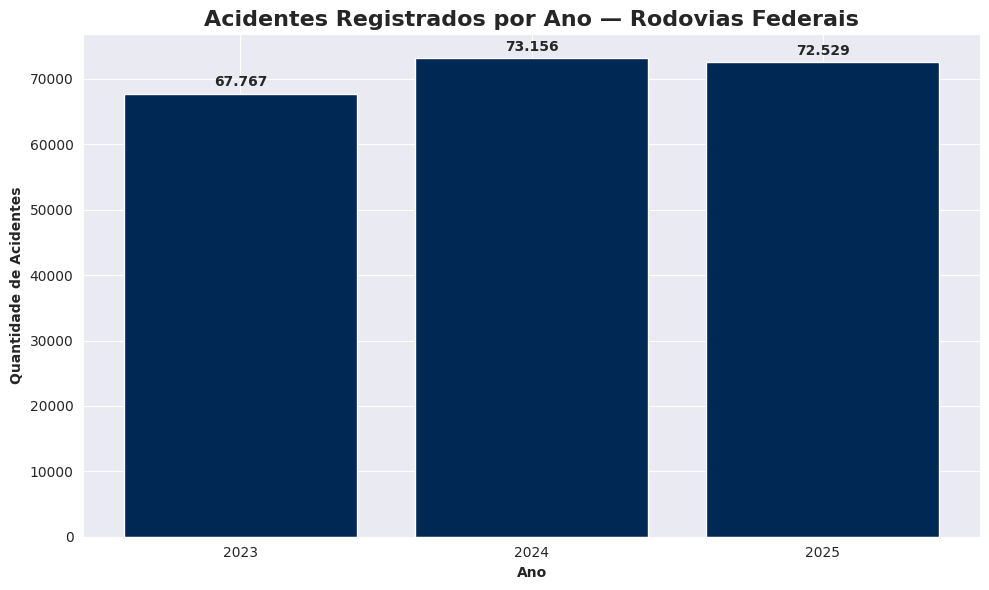

In [ ]:
plt.figure(figsize=(10, 6))
barras = plt.bar(acidentes_ano['ano_base'], acidentes_ano['quantidade'], color=AZUL_PRF)
rotulos = [formatar_numero_ptbr(v) for v in acidentes_ano['quantidade']]
plt.bar_label(barras, labels=rotulos, padding=3, fontweight='bold')

plt.title('Acidentes Registrados por Ano — Rodovias Federais', fontweight='bold', fontsize=16)
plt.xlabel('Ano', fontweight='bold')
plt.ylabel('Quantidade de Acidentes', fontweight='bold')
plt.tight_layout()
plt.show()


### **6.1 Variação por Estado (UF) entre anos consecutivos**

Aqui está uma das principais adaptações: em vez de uma única coluna `var_percentual` (2023→2024), calculamos a variação **para cada par de anos consecutivos** presente nos dados, de forma automática.

In [ ]:
df_uf_ano = (
    df_ocorrencias
    .groupby(['uf', 'ano_base'])
    .size()
    .reset_index(name='quantidade')
    .pivot(index='uf', columns='ano_base', values='quantidade')
    .fillna(0)
)

anos_ordenados = sorted(df_uf_ano.columns)
for ano_atual, ano_anterior in zip(anos_ordenados[1:], anos_ordenados[:-1]):
    coluna_var = f'var_{ano_anterior}_{ano_atual}'
    df_uf_ano[coluna_var] = round(
        (df_uf_ano[ano_atual] - df_uf_ano[ano_anterior]) / df_uf_ano[ano_anterior].replace(0, np.nan) * 100, 2
    )

df_uf_ano


ano_base,2023,2024,2025,var_2023_2024,var_2024_2025
uf,,,,,
AC,225,287,280,27.56,-2.44
AL,620,712,629,14.84,-11.66
AM,105,169,138,60.95,-18.34
AP,144,159,169,10.42,6.29
BA,3755,4151,4108,10.55,-1.04
CE,1363,1500,1302,10.05,-13.20
DF,978,1056,1011,7.98,-4.26
ES,2241,2395,2642,6.87,10.31
GO,3136,3305,3196,5.39,-3.30


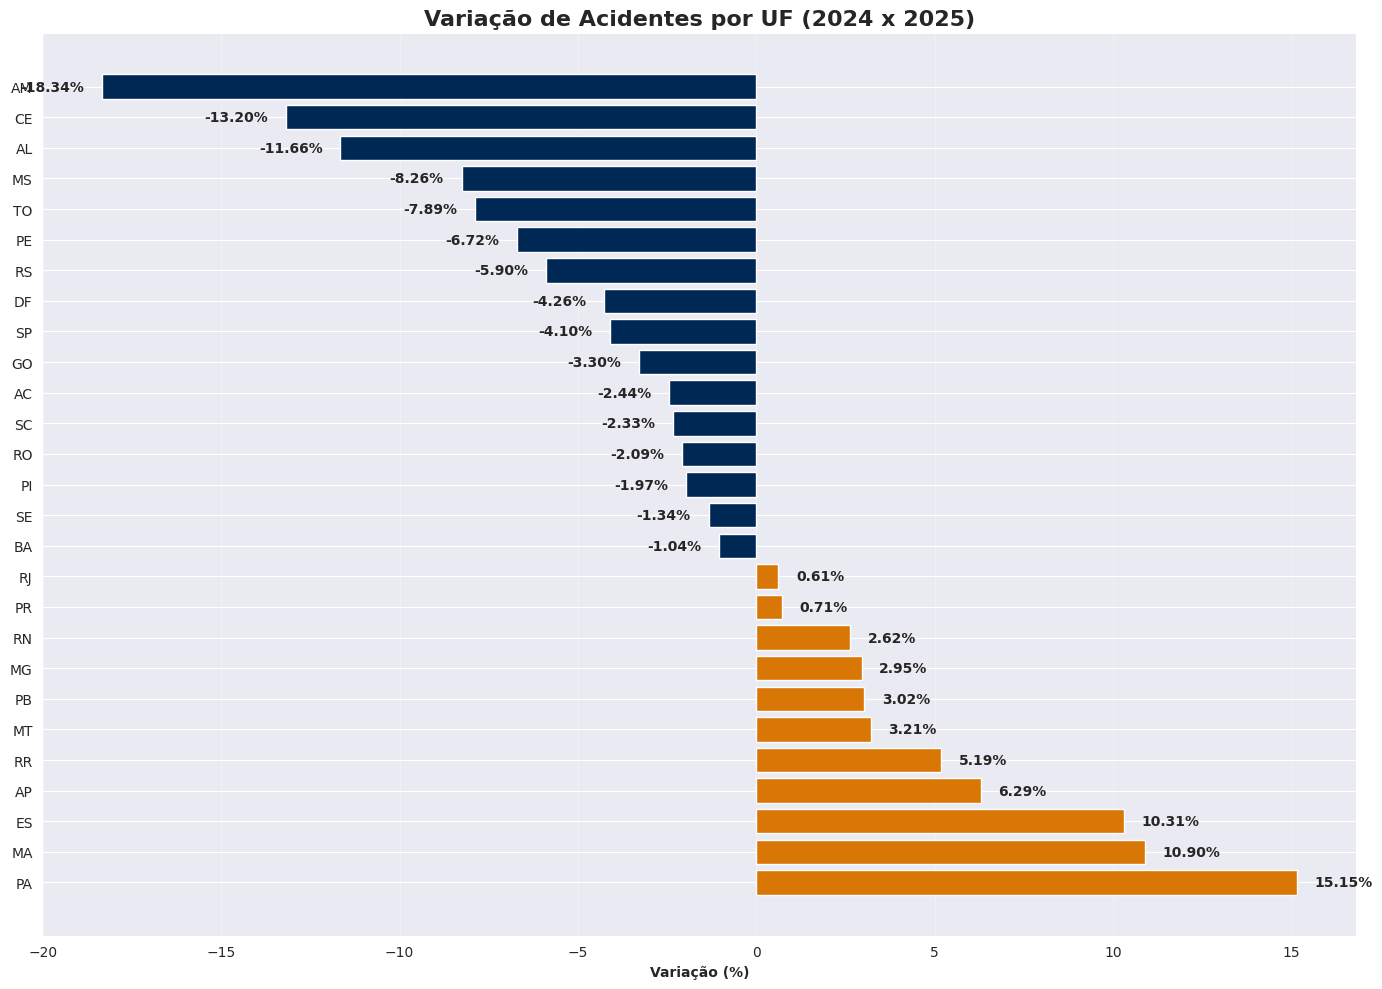

In [ ]:
# Gráfico divergente (cor indica o sinal da variação, não uma categoria fixa)
# — por isso não usa plot_barh_destaque, que assume duas cores fixas por categoria.
ultima_var = f'var_{anos_ordenados[-2]}_{anos_ordenados[-1]}'
df_uf_plot = df_uf_ano.reset_index().sort_values(by=ultima_var, ascending=False)
df_uf_plot['cor'] = df_uf_plot[ultima_var].apply(lambda x: AZUL_PRF if x <= 0 else DOURADO_DESTAQUE)

plt.figure(figsize=(14, 10))
plt.barh(df_uf_plot['uf'], df_uf_plot[ultima_var], color=df_uf_plot['cor'])

for i, v in enumerate(df_uf_plot[ultima_var]):
    plt.text(v + (0.5 if v >= 0 else -0.5), i, f'{v:.2f}%',
              ha='left' if v >= 0 else 'right', va='center', fontweight='bold')

plt.title(f'Variação de Acidentes por UF ({anos_ordenados[-2]} x {anos_ordenados[-1]})', fontsize=16, fontweight='bold')
plt.xlabel('Variação (%)', fontweight='bold')
plt.grid(axis='x', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()


#### 1. Destaques Globais e Maiores Volumes

| UF | Acidentes 2023 | Acidentes 2024 | Acidentes 2025 | Var. % 23–24 | Var. % 24–25 | Perfil da Tendência |
|:---:|:---:|:---:|:---:|:---:|:---:|:---|
| **MG** | 9.007 | 9.296 | 9.570 | +3,21% | **+2,95%** | **Crescimento Contínuo** (Líder Absoluto) |
| **SC** | 7.799 | 8.381 | 8.186 | +7,46% | -2,33% | Pico em 2024, leve recuo em 2025 |
| **PR** | 7.110 | 7.576 | 7.630 | +6,55% | +0,71% | Estabilização em patamar elevado |
| **RJ** | 5.575 | 6.389 | 6.428 | +14,60% | +0,61% | Salto em 2024 e sustentação em 2025 |
| **RS** | 4.936 | 5.206 | 4.899 | +5,47% | -5,90% | Retração em 2025 aos níveis de 2023 |

---

#### 2. Principais Achados Geográficos

- **Aceleração Crítica em 2025:**
  - **Pará (PA):** Registrou forte aceleração com alta de **+15,15%** em 2025 (de 970 para 1.117 ocorrências).
  - **Espírito Santo (ES):** Manteve curva ascendente de alta gravidade, acumulando **+10,31%** em 2025 (atingindo 2.642 acidentes).
  - **Maranhão (MA):** Após estabilidade em 2024, voltou a subir de forma expressiva (**+10,90%** em 2025).

- **Estados com Crescimento Sustentado em Ambos os Períodos:**
  - **MG, ES, PA, MT, PB, PR, RJ, RN e AP** foram as UFs que mantiveram variações percentuais positivas sucessivas em 2024 e 2025.

- **Reduções Mais Significativas em 2025:**
  - As maiores quedas relativas em 2025 ocorreram no **Amazonas (-18,34%)**, **Ceará (-13,20%)**, **Alagoas (-11,66%)** e **Mato Grosso do Sul (-8,26%)**.

> **Direcionamento Estratégico:** Enquanto a maioria das UFs acompanhou a tendência nacional de pico em 2024 com posterior estabilização em 2025, os estados com **crescimento contínuo (com destaque para MG, ES e PA)** devem ser priorizados em ações preventivas e reforço do policiamento ostensivo da PRF.

## **7. Distribuição dos Dados e Outliers**

As variáveis de contagem (pessoas, mortos, feridos, veículos) só existem, corretamente calculadas, em `df_ocorrencias`: por isso ela é utilizada aqui.

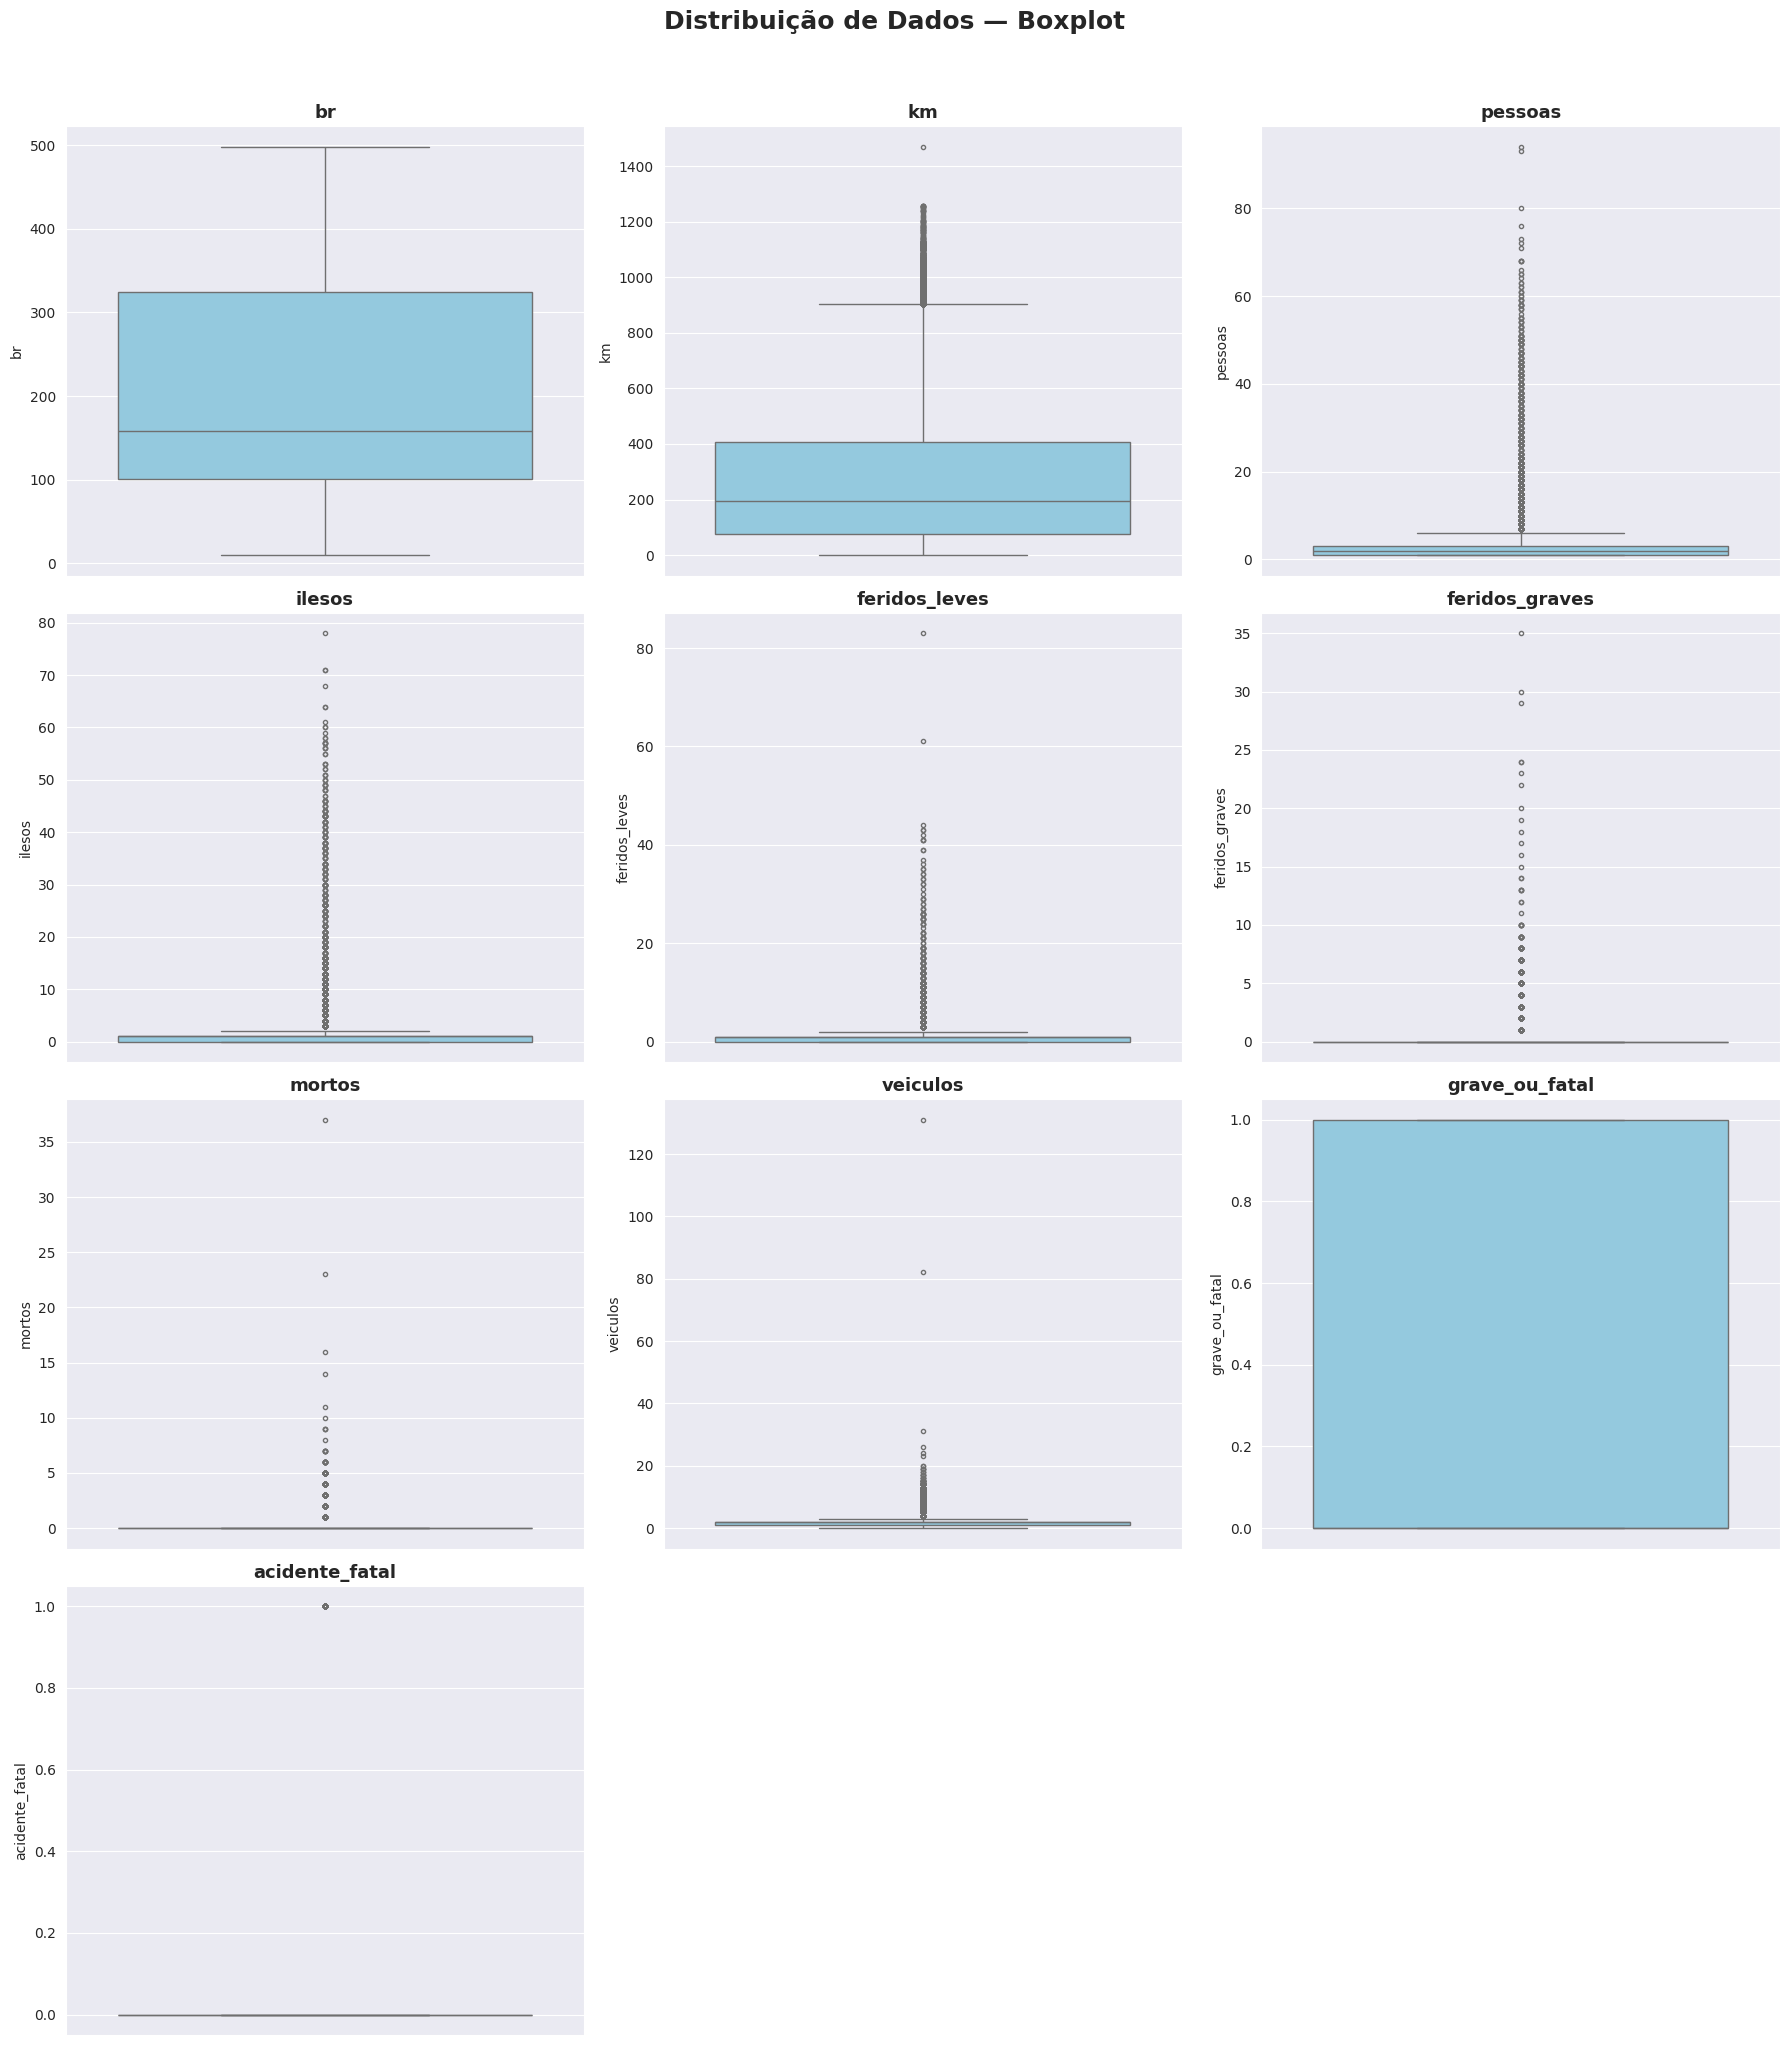

In [ ]:
box_plot(df_ocorrencias)


In [ ]:
relatorio_outliers(df_ocorrencias)

,coluna,qtd_total,qtd_outliers,percent_outliers,limite_inferior,limite_superior
0,feridos_graves,213452,48346,22.65,0.0,0.0
1,ilesos,213452,18460,8.65,-1.5,2.5
2,acidente_fatal,213452,15290,7.16,0.0,0.0
3,mortos,213452,15290,7.16,0.0,0.0
4,veiculos,213452,14250,6.68,-0.5,3.5
5,feridos_leves,213452,9022,4.23,-1.5,2.5
6,pessoas,213452,4405,2.06,-2.0,6.0
7,km,212939,2261,1.06,-419.5,904.5
8,br,212939,0,0.00,-233.5,658.5
9,grave_ou_fatal,213452,0,0.00,-1.5,2.5


Avaliação da presença de valores discrepantes (outliers) identificados pelo método do Intervalo Interquartil ($IQR = Q3 - Q1$), considerando o Limite Superior em $Q3 + 1,5 \times IQR$:

| Variável | Total Registros | Qtd. Outliers | % Outliers | Limite Inferior | Limite Superior | Interpretação do Limite |
|---|:---:|:---:|:---:|:---:|:---:|---|
| **feridos_graves** | 213.452 | 48.346 | **22,65%** | 0,0 | 0,0 | Acidentes com $\ge 1$ ferido grave |
| **ilesos** | 213.452 | 18.460 | **8,65%** | -1,5 | 2,5 | Acidentes com $> 2$ ilesos |
| **acidente_fatal** | 213.452 | 15.290 | **7,16%** | 0,0 | 0,0 | Acidentes com $\ge 1$ morto |
| **mortos** | 213.452 | 15.290 | **7,16%** | 0,0 | 0,0 | Acidentes com $\ge 1$ morto |
| **veiculos** | 213.452 | 14.250 | **6,68%** | -0,5 | 3,5 | Acidentes com $\ge 4$ veículos |
| **feridos_leves** | 213.452 | 9.022 | **4,23%** | -1,5 | 2,5 | Acidentes com $> 2$ feridos leves |
| **pessoas** | 213.452 | 4.405 | **2,06%** | -2,0 | 6,0 | Acidentes com $> 6$ pessoas |
| **km** | 212.939 | 2.261 | **1,06%** | -419,5 | 904,5 | Trechos de rodovias $> 904,5$ km |
| **br** | 212.939 | 0 | **0,00%** | -233,5 | 658,5 | Código da rodovia (Sem outliers) |

---

#### Principais Achados e Diretrizes de Tratamento

1. **Comportamento das Variáveis de Severidade (Zero-Inflation):**
   - As variáveis `feridos_graves`, `mortos` e `acidente_fatal` possuem mediana e 3º Quartil ($Q3$) iguais a `0`.
   - Por conta do cálculo estatístico do IQR, qualquer acidente com pelo menos 1 vítima grave ou fatal é rotulado como "outlier".
   - **Decisão Metodológica:** **Nenhum destes registros será removido.** Trata-se de um comportamento intrínseco de bases de acidentes de trânsito (eventos raros, porém de altíssimo impacto), sendo essenciais para a modelagem de risco e segurança viária.

2. **Sinistros de Grande Porte e Engavetamentos:**
   - **6,68% dos acidentes** envolvem 4 ou mais veículos, sinalizando colisões múltiplas e engavetamentos em rodovias.
   - **2,06% dos acidentes** envolvem mais de 6 pessoas, refletindo sinistros com veículos de transporte coletivo (ônibus/vans) ou de passeio com capacidade máxima.


### Investigação de Valores Extremos e Qualidade dos Dados

Após a análise da distribuição via IQR, na célula abaixo, é aplicada uma investigação aprofundada sobre os valores atípicos (outliers) registrados nas variáveis de volume e gravidade, dividida em três frentes:

---

#### 1. Engavetamentos Massivos (`veiculos >= 10`)
- **Critério:** Acidentes envolvendo 10 ou mais veículos simultaneamente.
- **Objetivo:** Mapear colisões múltiplas extremas, identificando rodovias (`br`), estados e condições meteorológicas propícias a engavetamentos (ex.: neblina, chuva intensa ou pista molhada).

---

#### 2. Sinistros Catastróficos e Transporte Coletivo (`mortos >= 5` ou `pessoas >= 30`)
- **Critério:** Ocorrências com 5 ou mais óbitos ou com mais de 30 pessoas envolvidas.
- **Objetivo:** Separar acidentes envolvendo veículos de grande porte e transporte de passageiros (ônibus/vans), analisando o impacto desses eventos isolados na severidade global da base.

---

#### 3. Auditoria de Integridade dos Dados (Sanity Check)
- **Verificação de Regras de Negócio:**
  - Identificação de registros onde `veiculos > pessoas` (inconsistência em que há mais veículos do que ocupantes declarados).
  - Validação da soma dos estados físicos (`ilesos + feridos_leves + feridos_graves + mortos == pessoas`).

> **Direcionamento:** Registros confirmados como eventos reais de alta gravidade são mantidos integralmente para representação fiel dos sinistros rodoviários. Eventuais incoerências cadastrais identificadas no *sanity check* serão tratadas ou isoladas para não viesar as análises estatísticas.

In [ ]:
# 1. Engavetamentos graves (>= 10 veículos)
df_engavetamentos = df_ocorrencias.query("veiculos >= 10")[
    ['id', 'data_inversa', 'uf', 'br', 'km', 'veiculos', 'pessoas', 'mortos', 'classificacao_acidente']
].sort_values(by='veiculos', ascending=False)

# 2. Sinistros de alta gravidade/transporte coletivo (>= 5 mortos ou >= 30 pessoas)
df_catastrofes = df_ocorrencias.query("mortos >= 5 or pessoas >= 30")[
    ['id', 'data_inversa', 'uf', 'br', 'km', 'pessoas', 'veiculos', 'mortos', 'feridos_graves', 'classificacao_acidente']
]

# 3. Sanity Check: Veículos > Pessoas (possíveis inconsistências de cadastro)
df_inconsistentes = df_ocorrencias.query("veiculos > pessoas")[
    ['id', 'data_inversa', 'uf', 'br', 'veiculos', 'pessoas']
]

print(f"Engavetamentos graves (>= 10 veículos): {len(df_engavetamentos)} registros")
print(f"Sinistros de alta gravidade/coletivos (>= 5 mortos ou >= 30 pessoas): {len(df_catastrofes)} registros")
print(f"Inconsistências cadastrais (veiculos > pessoas): {len(df_inconsistentes)} registros")

Engavetamentos graves (>= 10 veículos): 295 registros
Sinistros de alta gravidade/coletivos (>= 5 mortos ou >= 30 pessoas): 328 registros
Inconsistências cadastrais (veiculos > pessoas): 23487 registros


A auditoria nos registros extremos e nas regras de consistência da base `df_ocorrencias` revelou o seguinte diagnóstico:

| Categoria de Investigação | Critério de Filtro | Qtd. Registros | % da Base Total | Diagnóstico / Impacto |
|---|---|:---:|:---:|---|
| **Engavetamentos Graves** | `veiculos >= 10` | **295** | 0,14% | Outliers reais (colisões múltiplas extremas) |
| **Sinistros Catastróficos / Coletivos** | `mortos >= 5` ou `pessoas >= 30` | **328** | 0,15% | Outliers reais (ônibus/vans e acidentes de alta gravidade) |
| **Divergência Cadastral** | `veiculos > pessoas` | **23.487** | **11,00%** | Anomalia de preenchimento do BAT / Evasão de condutores |

---

####  Insights e Implicações Metodológicas

1. **Validação de Outliers de Volume:**
   - Tanto os engavetamentos (até 131 veículos) quanto os acidentes com múltiplas vítimas (até 37 mortos e 94 pessoas) representam **eventos reais e válidos**.
   - **Decisão:** Serão mantidos na base de dados para não comprometer o cálculo da severidade real do trânsito.

2. **Causa Raiz da Divergência (`veiculos > pessoas`):**
   - O volume expressivo de **23.487 ocorrências** com mais veículos do que pessoas cadastradas decorre de dinamismos operacionais da fiscalização:
     - **Evasão do local:** Condutores que evadiram sem prestação de socorro antes do registro oficial.
     - **Veículos estacionados ou abandonados:** Colisões envolvendo veículos parados no acostamento sem ocupantes.
     - **Incompletude no cadastro de ilesos:** Foco do preenchimento do BAT na qualificação dos envolvidos feridos/fatais, omitindo condutores ilesos em sinistros de menor gravidade.

> **Direcionamento Analítico:** Para análises que contabilizam **frota envolvida ou contagem absoluta de sinistros**, deve-se utilizar estritamente a visão `df_ocorrencias`. Para estudos demográficos, de faixa etária e perfil físico dos envolvidos, utiliza-se a visão `df_pessoas`, ciente de que há subnotificação residual de indivíduos ilesos.

## **8. Análise Temporal**

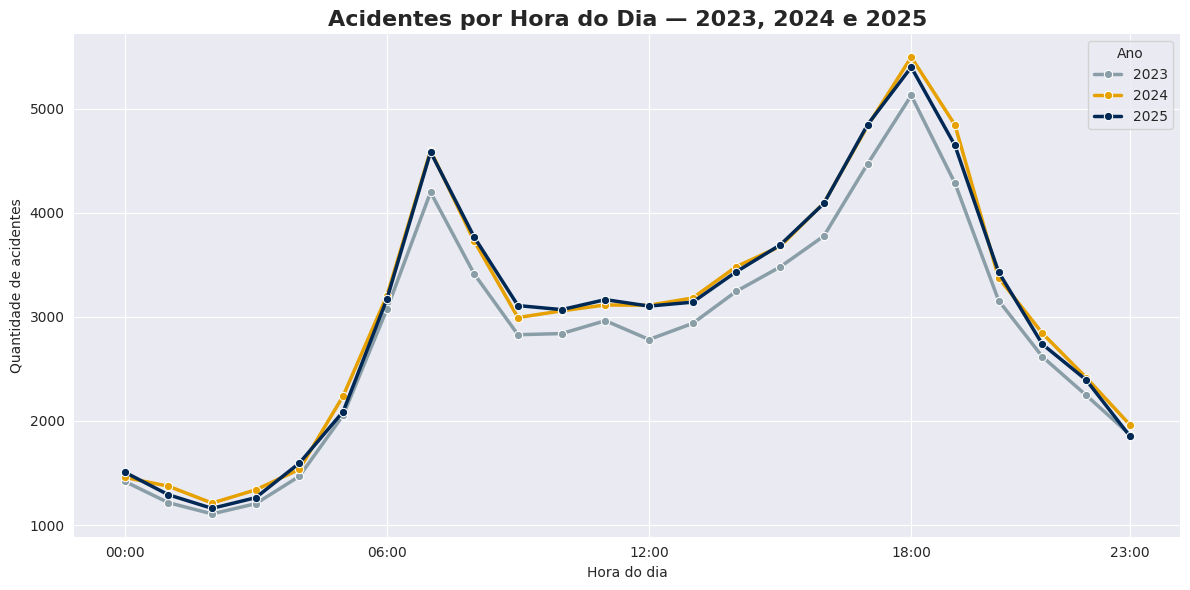

In [ ]:
df_ocorrencias['hora'] = df_ocorrencias['horario'].dt.hour

acidentes_por_hora_ano = (
    df_ocorrencias
    .groupby(['hora', 'ano_base'])
    .size()
    .reset_index(name='quantidade')
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=acidentes_por_hora_ano, x='hora', y='quantidade', hue='ano_base',
             palette=CORES_PRF_ANOS, linewidth=2.5, marker='o')

plt.title('Acidentes por Hora do Dia — 2023, 2024 e 2025', fontsize=16, fontweight='bold')
plt.xlabel('Hora do dia')
plt.ylabel('Quantidade de acidentes')
plt.xticks([0, 6, 12, 18, 23], ['00:00', '06:00', '12:00', '18:00', '23:00'])
plt.legend(title='Ano')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


#### Nuances da Comparação 2024 vs. 2025

- **Aceleração Matutina (07:00):** Em 2025, o volume de ocorrências às **07:00** superou o registrado em 2024, atingindo a marca máxima histórica para o turno da manhã.
- **Contenção no Superpico Noturno (18:00–23:00):** A redução global de -0,86% nos acidentes em 2025 é explicada prioritariamente pelo arrefecimento no período noturno. O ano de 2024 registrou o pico absoluto da série às 18:00, enquanto 2025 apresentou uma ligeira queda nessa janela crítica.
- **Sobreposição Diurna (09:00–16:00):** Ao longo do horário comercial, as curvas de 2024 e 2025 mantêm-se rigorosamente idênticas, consolidadas em patamar ~8% superior ao de 2023.

---

#### Síntese dos Achados Operacionais

1. **Janela Diária de Risco Máximo:** O intervalo entre **17:30 e 19:30** permanece como a faixa de maior Severidade Operacional da malha federal, acumulando o maior número de sinistros simultâneos.
2. **Ponto de Atenção em 2025:** O crescimento sustentado do pico das **07:00** aponta para a necessidade de atenção especial aos trechos urbanos/comutacionais durante o deslocamento matutino.

/tmp/ipykernel_3754/2700337420.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['dia_semana', 'hora'])


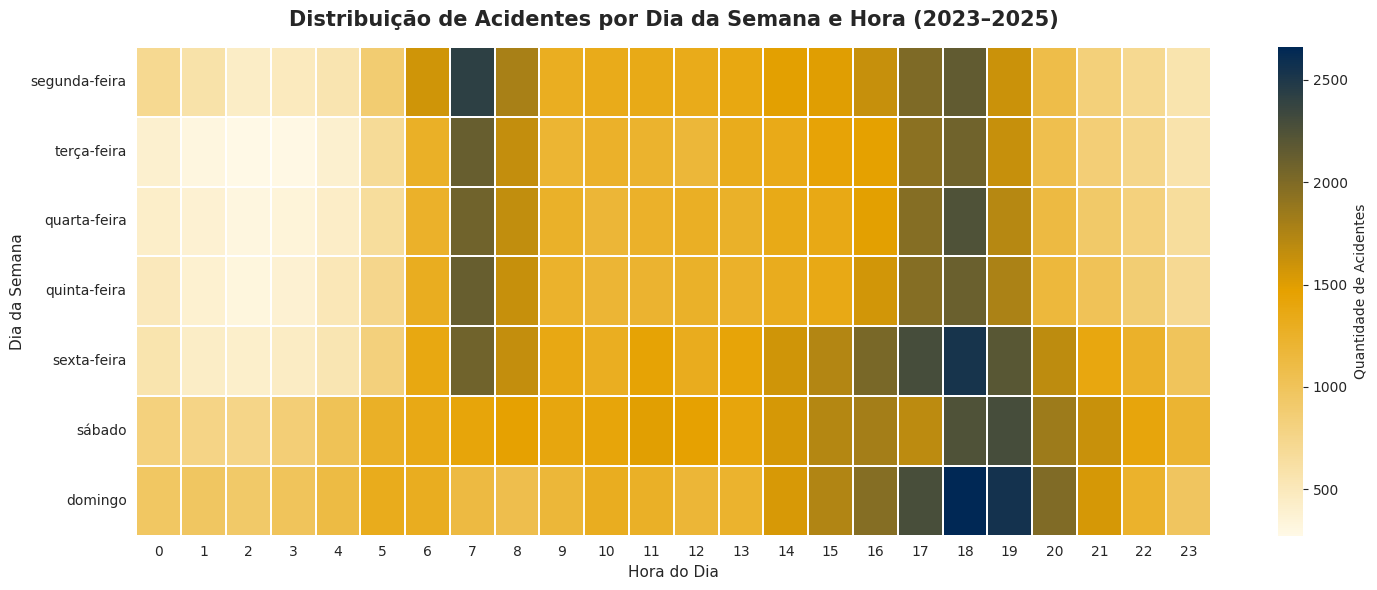

In [ ]:
tabela_calor = (
    df_ocorrencias
    .assign(dia_semana=lambda d: pd.Categorical(d['dia_semana'], categories=ORDEM_DIAS, ordered=True))
    .groupby(['dia_semana', 'hora'])
    .size()
    .reset_index(name='quantidade')
    .pivot(index='dia_semana', columns='hora', values='quantidade')
)

plt.figure(figsize=(15, 6))
sns.heatmap(
    tabela_calor,
    cmap=CMAP_PRF_SEQUENCIAL,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Quantidade de Acidentes'},
)

plt.title('Distribuição de Acidentes por Dia da Semana e Hora (2023–2025)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Hora do Dia', fontsize=11)
plt.ylabel('Dia da Semana', fontsize=11)
plt.tight_layout()
plt.show()


#### Mapeamento das Células de Calor (*Hotspots*)

| Zona de Risco | Dia e Horário Principal | Perfil da Ocorrência | Nível de Atensão |
|---|---|---|:---:|
| **Pico de Transição Semanal** | Sexta-feira, às 18:00 | Saída para o fim de semana / Transição comercial-lazer | **MÁXIMO** |
| **Pico de Retorno** | Domingo, das 18:00 às 19:00 | Retorno de viagens / Fluxo adensado em rodovias | **MÁXIMO** |
| **Pico Matutino Semanal** | Segunda-feira, às 07:00 | Reinício do tráfego pendular e comercial | **ALTO** |
| **Janela Noturna de Lazer** | Sábado e Domingo, das 00:00 às 05:00 | Tráfego noturno, fadiga, velocidade e consumo de álcool | **MÉDIO-ALTO** |

---

####  Síntese Operacional para Alocação de Recursos PRF

1. **Sexta-feira à Tarde/Noite (16h–20h):** Ponto cego de maior acúmulo de acidentes da semana. Exige posicionamento ostensivo em saídas de regiões metropolitanas e rodovias radiais.
2. **Domingo à Noite (17h–20h):** Foco na fiscalização de trechos de acostamento, ultrapassagens indevidas e velocidade em vias de pista simples.
3. **Madrugadas de Fim de Semana:** Manutenção de operações focadas no combate à condução sob efeito de álcool (Lei Seca) e fiscalização de radares em trechos urbanos.

## **9. Variáveis Categóricas**

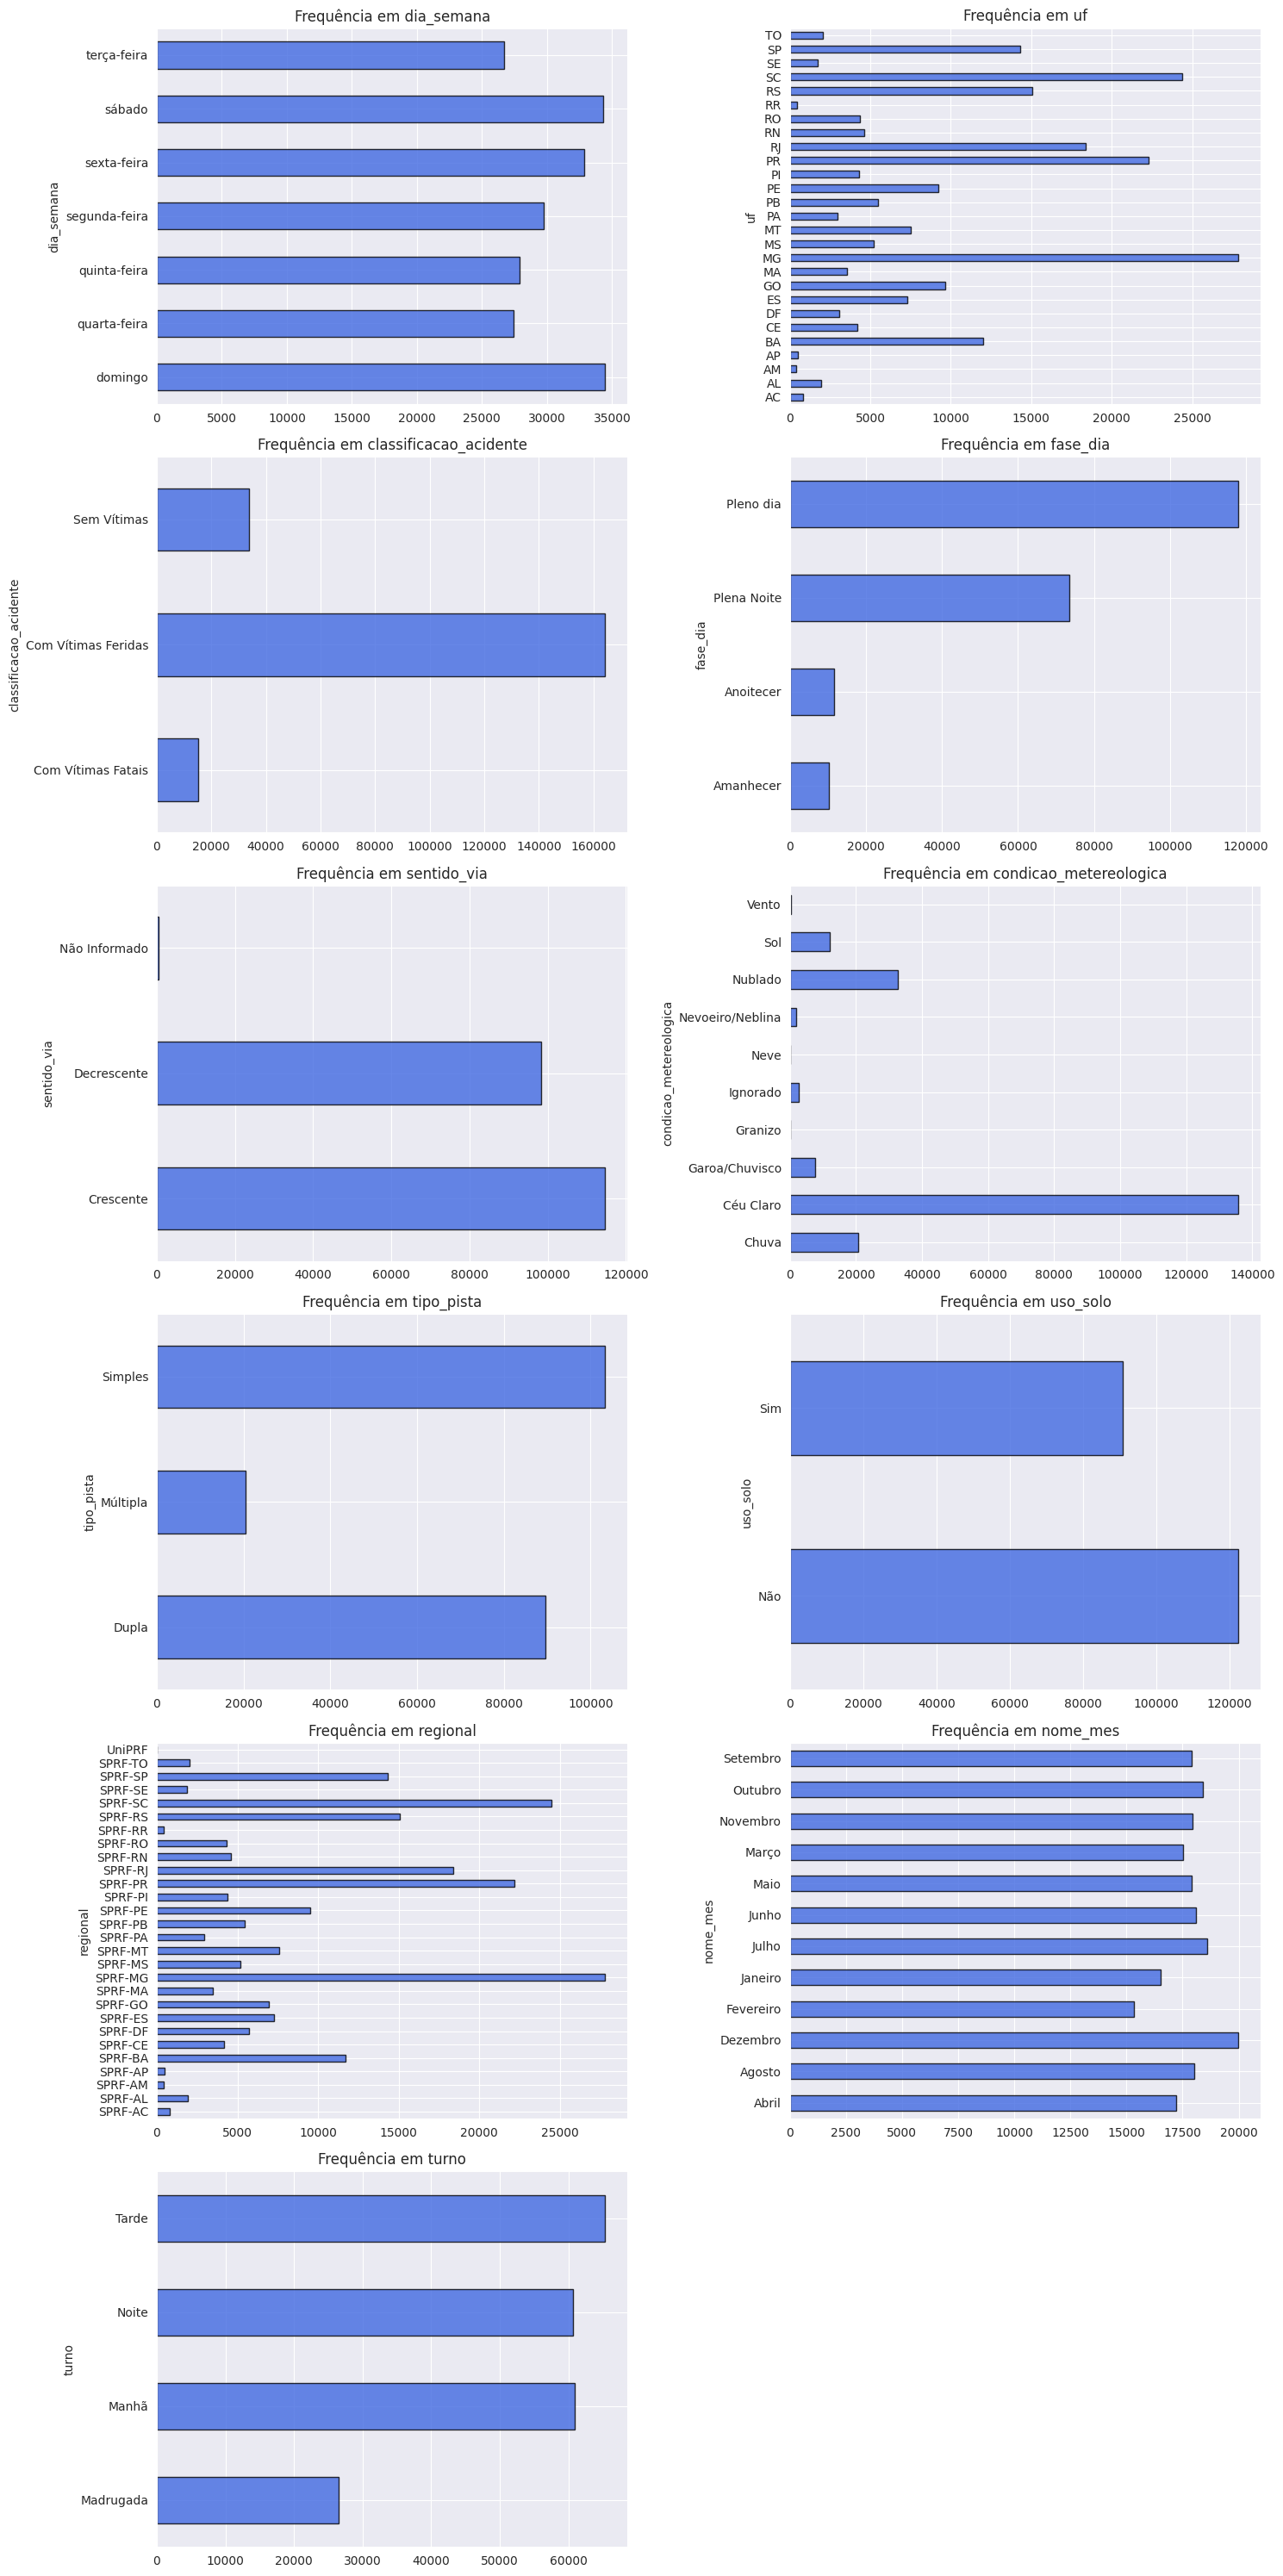

In [ ]:
frequencia_categorica(df_ocorrencias)


#### 1. Perfil Geográfico e Regionalidade
- **Minas Gerais (SPRF-MG):** Lidera isoladamente o ranking nacional com **~27,9 mil ocorrências**, refletindo a extensa malha rodoviária federal que integra o estado aos demais eixos logísticos do país.
- **Concentração no Sul/Sudeste:** As regionais de **SC (~24,4k)**, **PR (~22,3k)**, **RJ (~18,4k)**, **RS (~15,1k)** e **SP (~14,4k)** completam os maiores volumes do país.
- **Região Norte:** Apresenta volumes expressivamente menores (ex.: AM, AP, RR com $< 2$ mil acidentes cada), devido à menor extensão de rodovias federais pavimentadas.

---

#### 2. Sazonalidade Mensal (`nome_mes`)
- **Dezembro (Pico Absoluto):** Registra o maior volume do triênio (**~20.000 acidentes**), impulsionado pelo fluxo das festas de fim de ano e férias de verão.
- **Julho (Pico Secundário):** Concentra **~18,6 mil ocorrências**, associado às viagens das férias escolares de inverno.
- **Fevereiro (Menor Volume):** Registra o ponto mínimo (**~15,3 mil**), reflexo da menor quantidade de dias do mês.

---

#### 3. Infraestrutura da Via e Localização
- **Tipo de Pista:** **48,4% (~103,4 mil)** das ocorrências deram-se em **Pista Simples**, contra **~90 mil em Pista Dupla** e **~20 mil em Pista Múltipla**.
- **Uso do Solo:** **57,4% (~122,4 mil)** dos acidentes ocorreram **fora do perímetro urbano (área rural)**.
- **Sentido da Via:** Ligeira predominância no sentido **Crescente (~115 mil)** sobre o Decrescente (~98 mil).

> **Alerta de Risco:** A combinação de **pista simples em trechos rurais** é a mais propensa a sinistros gravíssimos, devido ao diferencial de velocidade praticado e ao risco de colisão frontal em ultrapassagens.

---

#### 4. Condições Ambientais e Luminosidade
- **Condição Meteorológica:** **63,6% (~135,8 mil)** dos acidentes ocorrem sob **Céu Claro**. Dias chuvosos somam apenas **~21 mil acidentes**.
- **Fase do Dia:** **55,3% (~118 mil)** ocorrem em **Pleno Dia**, seguidos de **34,6% (~74 mil) na Plena Noite**.

---

#### 5. Gravidade e Impacto Humano (`classificacao_acidente`)
- **Com Vítimas Feridas:** **77% (~164,3 mil acidentes)** — categoria predominante nas abordagens da PRF.
- **Sem Vítimas:** **16% (~34,1 mil acidentes)**.
- **Com Vítimas Fatais:** **7,2% (~15,3 mil acidentes)** — sinistros de severidade máxima.

> **Síntese dos Achados:** A maioria dos acidentes ocorre sob céu claro, em pleno dia, em pistas simples e fora das cidades. O perfil reforça que a impudência comportamental (excesso de velocidade, falta de atenção e ultrapassagens proibidas) é o vetor decisivo para a ocorrência das fatalidades.

## **10. Gravidade dos Acidentes**

### **10.1 Gravidade vs. tipo de pista**

In [ ]:
gravidade_pista = (
    df_ocorrencias
    .groupby('tipo_pista')
    .agg(total_acidentes=('id', 'count'), graves_fatais=('grave_ou_fatal', 'sum'))
    .assign(proporcao_graves_fatais=lambda d: round(d['graves_fatais'] / d['total_acidentes'] * 100, 2))
    .sort_values('proporcao_graves_fatais', ascending=False)
)
gravidade_pista


,total_acidentes,graves_fatais,proporcao_graves_fatais
tipo_pista,,,
Simples,103381,34977,33.83
Dupla,89524,20869,23.31
Múltipla,20547,4484,21.82


Avaliação do nível de gravidade dos acidentes (proporção de ocorrências com feridos graves ou mortos) em função da infraestrutura da rodovia:

| Tipo de Pista | Total de Acidentes | Acidentes Graves / Fatais | Proporção de Gravidade (%) | Nível de Risco Relativo |
|---|:---:|:---:|:---:|:---:|
| **Simples** | **103.381** | **34.977** | **33,83%** | **CRÍTICO** (1 em cada 3) |
| **Dupla** | 89.524 | 20.869 | **23,31%** | Moderado |
| **Múltipla** | 20.547 | 4.484 | **21,82%** | Menor Severidade |

---

#### Principais Achados e Recomendações de Engenharia Viária

1. **Pista Simples como Vetor Principal de Mortalidade:**
   - A pista simples concentra **57,98% de todos os acidentes graves e fatais** das rodovias federais no triênio (34.977 de 60.330).
   - A chance de um acidente ser grave/fatal em pista simples é **45% maior** do que em uma pista dupla ($33,83\% \div 23,31\%$).

2. **Efeito Protetor da Duplicação de Rodovias:**
   - A separação física dos fluxos opostos em pistas duplas/múltiplas reduz drasticamente a ocorrência de colisões frontais de altíssima energia, rebaixando a taxa de gravidade para o patamar de ~22%.

> **Direcionamento de Políticas Públicas:**
> - **Prioridade de Investimento:** Duplicação de trechos críticos de pista simples com alto volume de tráfego.
> - **Ações Operacionais PRF:** Instalação de radares e fiscalização ostensiva de ultrapassagens proibidas focada estritamente nos trechos de **pista simples**.

### **10.2 Gravidade vs. turno, por ano**

In [ ]:
gravidade_turno_ano = (
    df_ocorrencias
    .groupby(['ano_base', 'turno'])
    .agg(total_acidentes=('id', 'count'), graves_fatais=('grave_ou_fatal', 'sum'))
    .assign(proporcao=lambda d: round(d['graves_fatais'] / d['total_acidentes'] * 100, 2))
    .reset_index()
    .sort_values(['ano_base', 'proporcao'], ascending=[True, False])
)
gravidade_turno_ano


,ano_base,turno,total_acidentes,graves_fatais,proporcao
2,2023,Noite,19300,6407,33.2
0,2023,Madrugada,8470,2689,31.75
3,2023,Tarde,20688,5351,25.87
1,2023,Manhã,19309,4765,24.68
6,2024,Noite,20935,6796,32.46
4,2024,Madrugada,9156,2777,30.33
7,2024,Tarde,22377,5905,26.39
5,2024,Manhã,20688,5147,24.88
10,2025,Noite,20461,6585,32.18
8,2025,Madrugada,8907,2784,31.26


Avaliação da proporção de acidentes graves ou fatais (`grave_ou_fatal == 1`) cruzada por turno do dia e ano base:

| Ano | Turno | Total de Acidentes | Acidentes Graves/Fatais | Proporção de Gravidade (%) | Perfil de Risco Relativo |
|:---:|:---|:---:|:---:|:---:|:---|
| **2023** | **Noite** | 19.300 | 6.407 | **33,20%** | **Máximo** |
| **2023** | **Madrugada** | 8.470 | 2.689 | **31,75%** | Alto |
| **2023** | **Tarde** | 20.688 | 5.351 | **25,87%** | Moderado |
| **2023** | **Manhã** | 19.309 | 4.765 | **24,68%** | Menor Severidade |
| **2024** | **Noite** | 20.935 | 6.796 | **32,46%** | **Máximo** |
| **2024** | **Madrugada** | 9.156 | 2.777 | **30,33%** | Alto |
| **2024** | **Tarde** | 22.377 | 5.905 | **26,39%** | Moderado |
| **2024** | **Manhã** | 20.688 | 5.147 | **24,88%** | Menor Severidade |
| **2025** | **Noite** | 20.461 | 6.585 | **32,18%** | **Máximo** |
| **2025** | **Madrugada** | 8.907 | 2.784 | **31,26%** | Alto |
| **2025** | **Tarde** | 22.302 | 5.895 | **26,43%** | Moderado |
| **2025** | **Manhã** | 20.859 | 5.229 | **25,07%** | Menor Severidade |

---

#### Principais Achados

1. **Periculosidade do Período Noturno/Madrugada:**
   - A **Noite** lidera a taxa de severidade em todo o triênio (~32,2% a 33,2%), significando que **1 em cada 3 acidentes noturnos envolve vítimas graves ou mortes**.
   - A **Madrugada**, mesmo com menor volume de tráfego, sustenta a segunda maior taxa de gravidade (acima de 30% em todos os anos), impulsionada por fatores como fadiga, iluminação nula e velocidades mais elevadas.

2. **Tendência de Severidade Diurna em Alta:**
   - Houve um crescimento progressivo na proporção de acidentes graves nos turnos da **Manhã** (+0,39 p.p. de 2023 a 2025) e da **Tarde** (+0,56 p.p. de 2023 a 2025).

> **Direcionamento de Ações PRF:**
> - **Redução de Mortes (Foco Noturno):** Reforço de sinalização ostensiva, fiscalização de velocidade com equipamento infravermelho/portátil e radares nos trechos de maior movimento das 18h às 00h.
> - **Prevenção de Tráfico Pesado (Madrugada):** Fiscalização do tempo de descanso obrigatorio para motoristas de carga e passageiros (Lei do Motorista) entre 00h e 06h.

## **11. Acidentes por Rodovia (BR)**

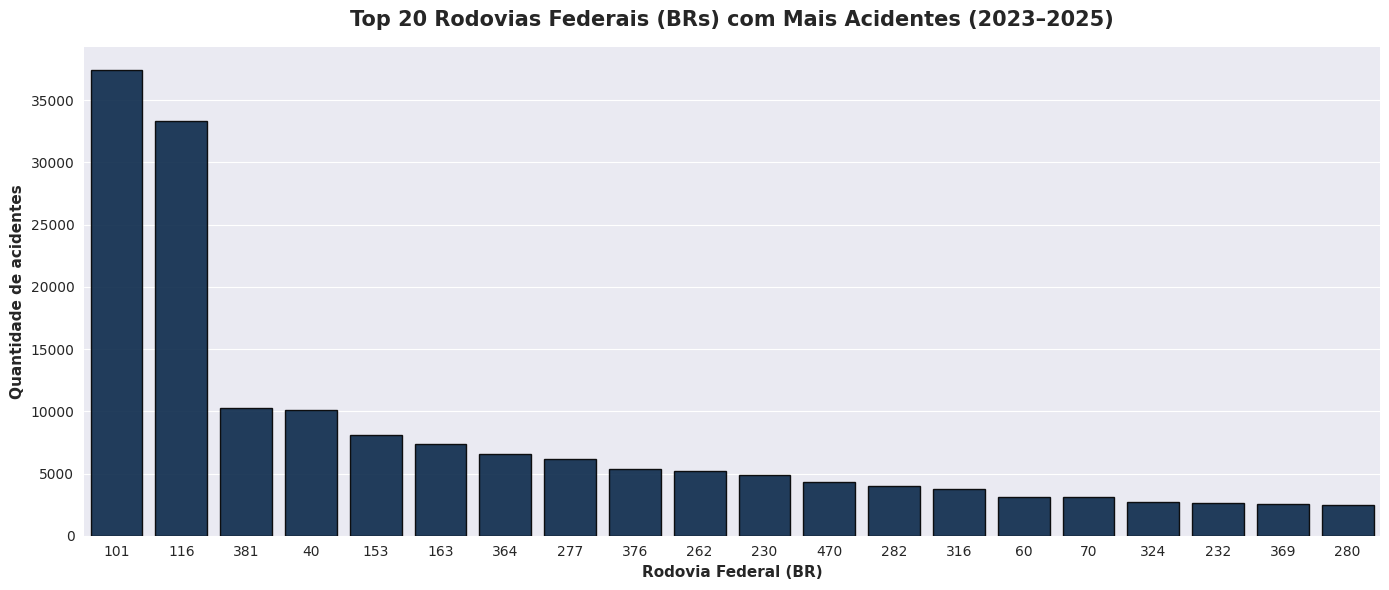

In [ ]:
df_top_brs = (
    df_ocorrencias.dropna(subset=['br'])
    .assign(br=lambda d: d['br'].astype(int).astype(str))  # Converte 101.0 -> '101'
    .groupby('br')
    .size()
    .reset_index(name='quantidade')
    .sort_values(by='quantidade', ascending=False)
    .head(20)
)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_top_brs, x='br', y='quantidade', color=AZUL_PRF, edgecolor='black', alpha=0.9)

plt.title('Top 20 Rodovias Federais (BRs) com Mais Acidentes (2023–2025)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Rodovia Federal (BR)', fontsize=11, fontweight='bold')
plt.ylabel('Quantidade de acidentes', fontsize=11, fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


Análise da distribuição espacial dos acidentes por rodovia federal na visão `df_ocorrencias`:

| Posição | Rodovia | Qtd. Acidentes (Aprox.) | Perfil e Abrangência Principal | Nível de Prioridade |
|:---:|:---:|:---:|---|:---:|
| **1º** | **BR-101** | **~37,5 mil** | Tronco litorâneo nacional (Norte–Sul) | **MÁXIMO** |
| **2º** | **BR-116** | **~33,5 mil** | Tronco central/litorâneo (Norte–Sul) | **MÁXIMO** |
| **3º** | **BR-381** | **~10,2 mil** | Conexão MG–SP (Fernão Dias / Rodovia da Morte) | **ALTO** |
| **4º** | **BR-040** | **~10,1 mil** | Conexão DF–GO–MG–RJ | **ALTO** |
| **5º** | **BR-153** | **~8,1 mil** | Transbrasiliana (Integração Nacional) | **ALTO** |

---

####  Principais Achados e Concentração de Risco

1. **Bipolo BR-101 e BR-116:**
   - As duas principais rodovias do país concentram isoladamente **1/3 de todos os acidentes registrados no Brasil (33,2%)**.
   - **Causa Primária do Volume:** Trata-se das rodovias de maior extensão e maior VMD (Volume Médio Diário de Veículos), cruzando as principais capitais e regiões metropolitanas do país.

2. **Gargalos Regionais Críticos:**
   - A presença marcante da **BR-381** e da **BR-040** no topo do ranking reflete diretamente a liderança de **Minas Gerais** no volume total de sinistros do país.

> **Direcionamento Estratégico:** A alocação de postos fixos, radares portáteis e reforço de efetivo em operações temáticas (Carnaval, Semana Santa e Fim de Ano) deve manter prioridade regulamentar e orçamentária para a **BR-101** e **BR-116**.

In [ ]:
top_brs_fatais = (
    df_ocorrencias.dropna(subset=['br'])
    .assign(br=lambda d: d['br'].astype(int).astype(str))
    .groupby('br')
    .agg(total_acidentes=('id', 'count'), acidentes_fatais=('acidente_fatal', 'sum'))
    .assign(proporcao_fatais=lambda d: (d['acidentes_fatais'] / d['total_acidentes'] * 100).round(2))
    .query('total_acidentes >= 30', engine='python')  # engine='python' evita RuntimeWarning
    .sort_values(by='proporcao_fatais', ascending=False)
    .head(20)
    .reset_index()
)

df_destacado = top_brs_fatais.style.background_gradient(
    subset=['proporcao_fatais'], cmap=CMAP_PRF_SEQUENCIAL
).format({
    'proporcao_fatais': '{:.2f}%',
    'total_acidentes': '{:,}',
    'acidentes_fatais': '{:,}',
})

display(df_destacado)


,br,total_acidentes,acidentes_fatais,proporcao_fatais
0,420,73,25,34.25%
1,30,79,22,27.85%
2,308,95,26,27.37%
3,412,80,21,26.25%
4,402,178,44,24.72%
5,349,91,22,24.18%
6,429,83,17,20.48%
7,432,60,12,20.00%
8,361,113,22,19.47%
9,317,135,26,19.26%


Análise da proporção de acidentes fatais (`acidente_fatal == 1`) por rodovia federal na visão `df_ocorrencias` (filtro de corte: $\ge 30$ acidentes no triênio):

| Ranking | Rodovia | Total Acidentes | Acidentes Fatais | Proporção Fatal (%) | Diagnóstico de Risco |
|:---:|:---:|:---:|:---:|:---:|---|
| **1º** | **BR-420** | 73 | 25 | **34,25%** | **Mortalidade Extrema** ($> 1/3$ dos acidentes) |
| **2º** | **BR-530** | 79 | 22 | **27,85%** | Risco Crítico |
| **3º** | **BR-308** | 95 | 26 | **27,37%** | Risco Crítico |
| **4º** | **BR-412** | 80 | 21 | **26,25%** | Risco Crítico |
| **5º** | **BR-402** | 178 | 44 | **24,72%** | Risco Crítico |
| ... | ... | ... | ... | ... | ... |
| **18º** | **BR-210** | 1.443 | 225 | **15,59%** | Alto Volume + Alta Lethalidade |
| **19º** | **BR-222** | 1.749 | 271 | **15,49%** | Alto Volume + Alta Lethalidade |
| **20º** | **BR-316** | **3.728** | **569** | **15,26%** | **Maior Volume Fatal Absoluto do Ranking** |

---

####  Principais Achados e Recomendações

1. **Divergência entre Volume e Severity:**
   - As rodovias com maior volume de sinistros do país (BR-101 e BR-116) possuem taxas de fatalidade menores em termos percentuais por contarem com maior extensão de pistas duplas/múltiplas.
   - Trechos de menor fluxo em pista simples (ex.: BR-420, BR-530, BR-308) apresentam taxas de óbito desproporcionalmente elevadas devido à combinação de pista simples, falta de acostamento e resgate médico distante.

2. **Ponto Crítico Integrado: BR-316:**
   - A **BR-316** exige intervenção prioritária imediata: acumula **3.728 acidentes e 569 acidentes com mortes**, combinando alto tráfego com taxa de mortalidade acima de 15%.

> **Direcionamento Operacional da PRF:**
> - **Fiscalização Punitiva/Velocidade:** Instalação de radares fixos e operações de combate à ultrapassagem indevida nas rodovias líderes em taxa percentual (BR-420, BR-530, BR-308, BR-412).
> - **Presença Ostensiva Contínua:** Reforço de patrulhamento ao longo de toda a extensão da **BR-316**.

## **12. Relação entre Causas e Tipos de Acidente**

Como cada linha de `df_prf` já é uma combinação (pessoa × causa × tipo), contar `causa_acidente` x `tipo_acidente` direto em `df_prf` infla a frequência pelo número de pessoas envolvidas em cada acidente. A contagem correta é por **acidente**: cada combinação causa/tipo deve ser contada uma vez por `id`, não uma vez por pessoa.

In [ ]:
causas_tipos_por_acidente = df_prf.drop_duplicates(subset=['id', 'causa_acidente', 'tipo_acidente'])

causas_tipos = (
    causas_tipos_por_acidente
    .groupby(['causa_acidente', 'tipo_acidente'])
    .size()
    .reset_index(name='quantidade')
    .sort_values('quantidade', ascending=False)
)
causas_tipos.head(40)


,causa_acidente,tipo_acidente,quantidade
7,Acessar a via sem observar a presença dos outr...,Colisão transversal,14951
234,Condutor deixou de manter distância do veículo...,Colisão traseira,14569
906,Reação tardia ou ineficiente do condutor,Tombamento,14371
903,Reação tardia ou ineficiente do condutor,Queda de ocupante de veículo,13758
140,Ausência de reação do condutor,Queda de ocupante de veículo,13015
898,Reação tardia ou ineficiente do condutor,Colisão traseira,12864
135,Ausência de reação do condutor,Colisão traseira,12559
143,Ausência de reação do condutor,Tombamento,12478
904,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,12222
141,Ausência de reação do condutor,Saída de leito carroçável,11177


Análise do cruzamento entre as causas primárias e as tipologias de impacto mais frequentes registradas pela PRF no triênio (2023–2025):

#### 1. Principais Combinações em Volume Absoluto

| Causa Principal do Acidente | Tipo de Acidente Derivado | Qtd. Registros | Diagnóstico da Dinâmica Viária |
|---|---|:---:|---|
| **Acessar a via sem observar os outros** | **Colisão transversal** | **14.951** | **Líder Absoluto:** Conflito em cruzamentos, trevos e acessos |
| **Falta de distância de segurança** | **Colisão traseira** | **14.569** | Tráfego adensado e desacelerações repentinas |
| **Reação tardia ou ineficiente** | **Tombamento** | **14.371** | Perda de estabilidade em manobras evasivas bruscas |
| **Reação tardia ou ineficiente** | **Queda de ocupante** | **13.758** | Vulnerabilidade de motociclistas/ciclistas |
| **Ausência de reação do condutor** | **Queda de ocupante** | **13.015** | Distração severa em veículos de duas rodas |
| **Reação tardia ou ineficiente** | **Colisão traseira** | **12.864** | Desatenção ao fluxo frontal |
| **Ausência de reação do condutor** | **Colisão traseira** | **12.559** | Inatenção total (ex.: uso de smartphone/dispositivos) |
| **Ausência de reação do condutor** | **Tombamento** | **12.478** | Perda de controle do veículo por distração |
| **Reação tardia ou ineficiente** | **Saída de leito carroçável** | **12.222** | Saída de pista ao tentar corrigir a trajetória |
| **Ausência de reação do condutor** | **Saída de leito carroçável** | **11.177** | Desvio involuntário do leito da rodovia |
| **Velocidade Incompatível** | **Saída de leito carroçável** | **10.225** | Excesso de velocidade em curvas e trechos críticos |

---

#### 2. Destaques de Alta Severidade e Fatores de Incapacitação

- **Colisão Frontal por Contramão (5.853 acidentes):** A combinação de *"Transitar na contramão"* com *"Colisão frontal"* representa o par de maior letalidade proporcional nas rodovias federais.
- **Incapacitação Psicomotora (Álcool e Sono):**
  - *"Ingestão de álcool"* $\rightarrow$ *"Saída de leito carroçável"*: **5.850 ocorrências**.
  - *"Condutor dormindo"* $\rightarrow$ *"Saída de leito carroçável"*: **5.622 ocorrências**.
- **Fatores de Manutenção e Clima:**
  - *"Falhas mecânicas/elétricas"* $\rightarrow$ *"Incêndio"*: **4.600 acidentes**.
  - *"Pista Molhada / Chuva"* $\rightarrow$ *"Saída de leito carroçável"*: **3.767 acidentes**.

---

#### Recomendações de Engenharia Viária e Fiscalização

1. **Engenharia de Tráfego:** Reorganização e desnivelamento de acessos urbanos e trevos onde o conflito de *"Acesso à via x Colisão transversal"* é crônico.
2. **Fiscalização direcionada:** Intensificação de radares portáteis de velocidade antes de curvas acentuadas (*Velocidade Incompatível x Saída de leito*) e fiscalização ostensiva de ultrapassagens em trechos de pista simples (*Contramão x Colisão frontal*).

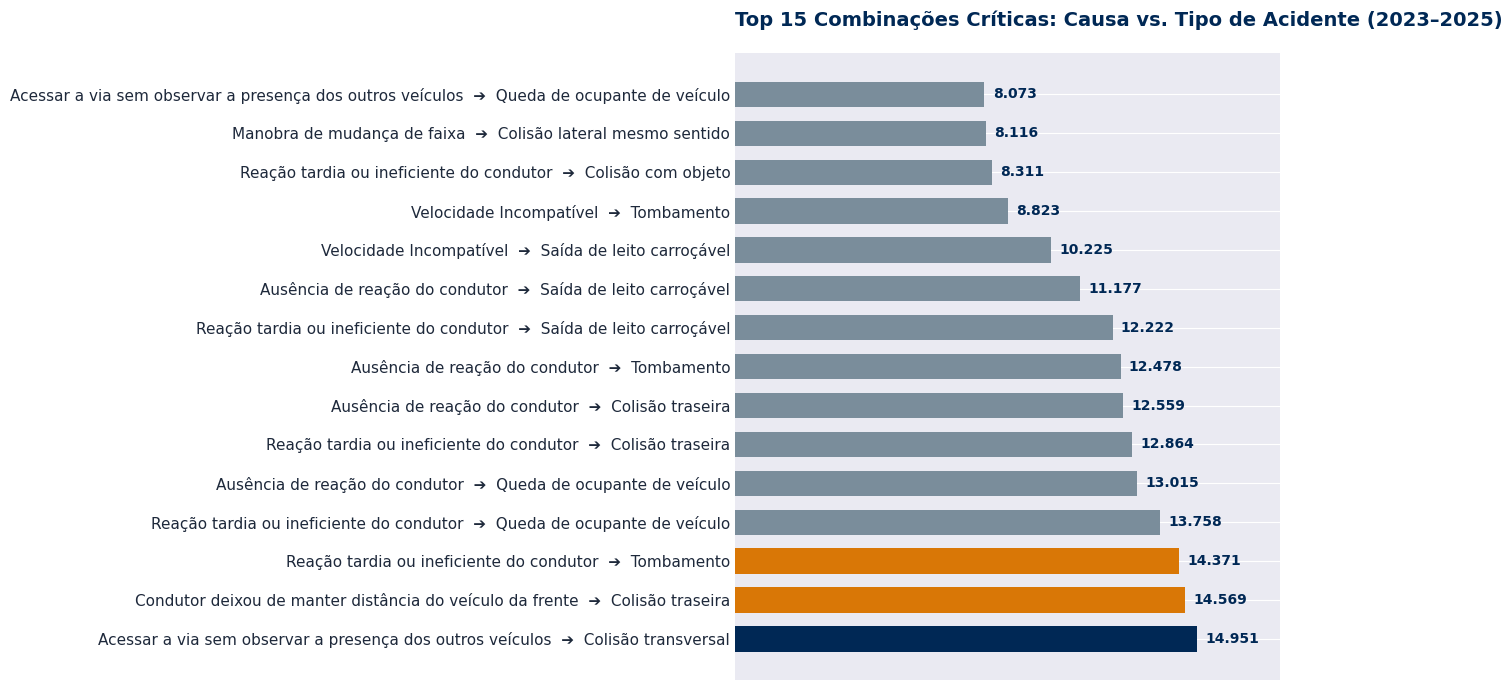

(<Figure size 1300x700 with 1 Axes>,
 <Axes: title={'left': 'Top 15 Combinações Críticas: Causa vs. Tipo de Acidente (2023–2025)'}>)

In [ ]:
df_story = causas_tipos.head(15).copy()
df_story['par_causa_tipo'] = df_story['causa_acidente'] + '  ➔  ' + df_story['tipo_acidente']

# Destaque em 3 níveis: 1º colocado (azul), 2º-3º (dourado), demais (cinza neutro)
cores_destaque = (
    [AZUL_PRF] + [DOURADO_DESTAQUE] * 2 + [CORES_PRF['cinza_neutro']] * (len(df_story) - 3)
)

plot_barh_destaque(
    df_story, 'par_causa_tipo', 'quantidade',
    titulo='Top 15 Combinações Críticas: Causa vs. Tipo de Acidente (2023–2025)',
    cores=cores_destaque, figsize=(13, 7),
)


| Ranking | Causa do Acidente ➔ Tipo do Acidente | Quantidade Absoluta | Destaque e Nível de Impacto |
|:---:|---|:---:|:---:|
| **1º** | **Acessar a via sem observar a presença dos outros ➔ Colisão transversal** | **14.951** | **LÍDER ABSOLUTO (Azul PRF - `#002B5C`)** |
| **2º** | **Condutor deixou de manter distância do veículo da frente ➔ Colisão traseira** | **14.569** | **ALTA CRITICIDADE (Amarelo PRF - `#E6A100`)** |
| **3º** | **Reação tardia ou ineficiente do condutor ➔ Tombamento** | **14.371** | **ALTA CRITICIDADE (Amarelo PRF - `#E6A100`)** |
| **4º** | **Reação tardia ou ineficiente do condutor ➔ Queda de ocupante de veículo** | **13.758** | Relevante |
| **5º** | **Ausência de reação do condutor ➔ Queda de ocupante de veículo** | **13.015** | Relevante |
| **6º** | **Reação tardia ou ineficiente do condutor ➔ Colisão traseira** | **12.864** | Relevante |
| **7º** | **Ausência de reação do condutor ➔ Colisão traseira** | **12.559** | Relevante |
| **8º** | **Ausência de reação do condutor ➔ Tombamento** | **12.478** | Relevante |
| **9º** | **Reação tardia ou ineficiente do condutor ➔ Saída de leito carroçável** | **12.222** | Relevante |
| **10º** | **Ausência de reação do condutor ➔ Saída de leito carroçável** | **11.177** | Relevante |
| **11º** | **Velocidade Incompatível ➔ Saída de leito carroçável** | **10.225** | Relevante |
| **12º** | **Velocidade Incompatível ➔ Tombamento** | **8.823** | Relevante |
| **13º** | **Reação tardia ou ineficiente do condutor ➔ Colisão com objeto** | **8.311** | Relevante |
| **14º** | **Manobra de mudança de faixa ➔ Colisão lateral mesmo sentido** | **8.116** | Relevante |
| **15º** | **Acessar a via sem observar a presença dos outros ➔ Queda de ocupante** | **8.073** | Relevante |

---

#### Agrupamento Estratégico dos Achados (*Clusters* de Risco)

1. **Gargalo de Entrada na Rodovia (Top 1 Absoluto — 14.951 casos):**
   - A combinação de *Acesso indevido à via* gerando *Colisão Transversal* lidera o país[cite: 14]. Aponta para necessidade urgente de reengenharia em acessos urbanos, retornos em nível e entroncamentos de rodovias[cite: 14].

2. **Epidemia da Distração e Atraso Cognitivo (>96 mil casos acumulados):**
   - As falhas de percepção (*Reação tardia/ineficiente* e *Ausência de reação*) dominam 8 das 15 posições[cite: 14]. Provocam desde acidentes em sequência (*Colisões Traseiras*) até perdas bruscas de controle (*Tombamentos* e *Saídas de Pista*)[cite: 14].

3. **Vulnerabilidade em Duas Rodas (34.846 casos):**
   - A *Queda de ocupante de veículo* aparece em 3 combinações de alto volume (#4, #5 e #15)[cite: 14], ressaltando a altíssima sensibilidade de motociclistas a qualquer desatenção ou fechada na via[cite: 14].

---

####  Recomendações Estratégicas para a PRF

- **Engenharia:** Sinalização reforçada e iluminação ostensiva em acessos secundários às rodovias federais.
- **Fiscalização Operacional:** Foco em manter distância de segurança e combate ao uso do celular ao volante nas rodovias de maior densidade de tráfego.

## **13. Análise Geoespacial**


In [ ]:
gdf = gpd.GeoDataFrame(
    df_ocorrencias,
    geometry=gpd.points_from_xy(df_ocorrencias['longitude'], df_ocorrencias['latitude']),
    crs='EPSG:4326',
)

brasil = geobr.read_country(year=2020)


/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
country_2020_simplified.parquet: 100%|██████████| 532k/532k [00:00<00:00, 14.8MB/s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

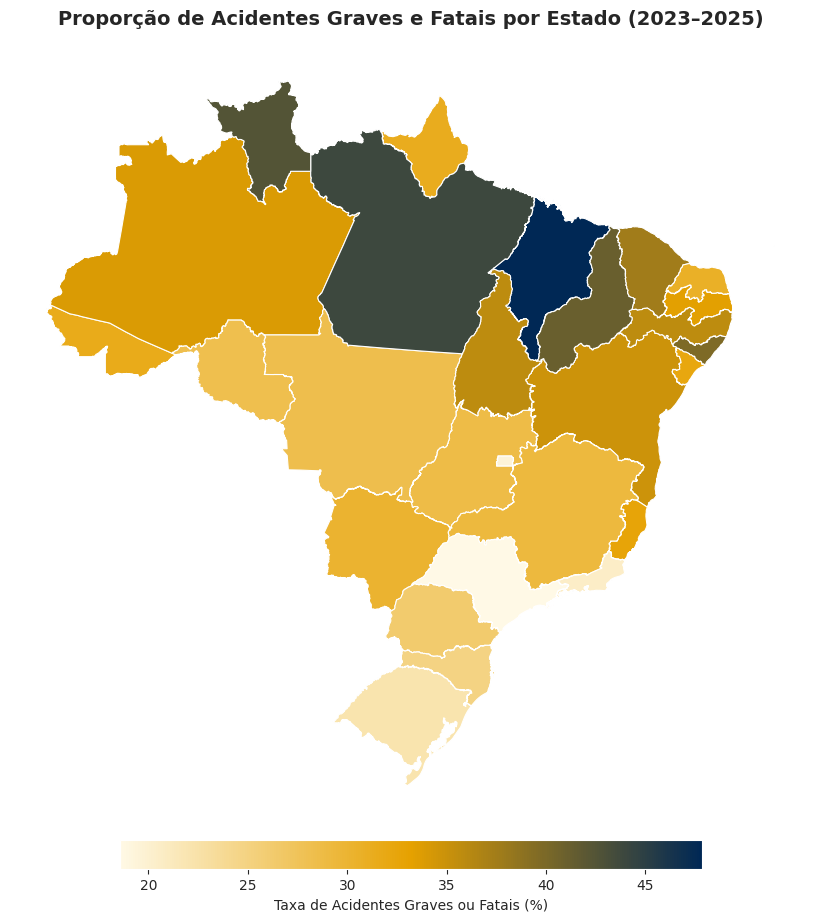

In [ ]:
url_br_uf = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
gdf_br_uf = gpd.read_file(url_br_uf)

uf_gravidade = (
    df_ocorrencias.groupby('uf')
    .agg(total_acidentes=('id', 'count'), graves_fatais=('grave_ou_fatal', 'sum'))
    .assign(pct_grave_fatal=lambda d: (d['graves_fatais'] / d['total_acidentes']) * 100)
    .reset_index()
)

gdf_mapa = gdf_br_uf.merge(uf_gravidade, left_on='sigla', right_on='uf')

fig, ax = plt.subplots(figsize=(10, 10))
gdf_mapa.plot(
    column='pct_grave_fatal',
    cmap=CMAP_PRF_SEQUENCIAL,
    linewidth=0.8,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': 'Taxa de Acidentes Graves ou Fatais (%)',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02,
    },
    ax=ax,
)

plt.title('Proporção de Acidentes Graves e Fatais por Estado (2023–2025)', fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()


A visualização coroplética agregada apresenta a **Proporção de Acidentes Graves e Fatais** (`pct_grave_fatal = (graves + mortos) / total_acidentes * 100`) por estado, eliminando o viés do volume absoluto de frota:

#### 1. Mapeamento dos Extremos de Severidade

| Cluster Regional | Estados Representativos | Faixa de Gravidade (%) | Perfil Operacional e Infraestrutura |
|---|---|:---:|---|
| **Severidade Extrema** | **Maranhão (MA)** | **> 45%** | **Ponto Crítico Nacional:** Quase 1 em cada 2 acidentes é grave ou fatal |
| **Alta Severidade** | **PA, PI, AP, RR** | **35% a 42%** | Predomínio de pista simples, longas distâncias e socorro distante |
| **Severidade Intermediária** | **BA, TO, AM, CE, PE, RN, PB, AL, SE** | **30% a 35%** | Trajetos mistos com forte presença de veículos vulneráveis |
| **Severidade Moderada** | **MT, MS, GO, ES, AC** | **25% a 30%** | Corredores agrícolas e de transição regional |
| **Menor Severidade Proporcional** | **MG, SP, RJ, PR, SC, RS** | **20% a 25%** | Alto volume total, porém com maior proporção de colisões leves em tráfego denso |

---

#### Principais Achados

1. **O Paradoxos Volume vs. Letalidade:**
   - Estados do Sul e Sudeste acumulam a maioria dos acidentes em números absolutos, mas apresentam as **menores taxas percentuais de gravidade** (tom creme no mapa, ~20–25%).
   - Em contrapartida, estados do Norte e Nordeste registram menor volume absoluto de ocorrências, porém com **taxas de gravidade desproporcionalmente elevadas** (tons escuros/azul-marinho, atingindo >45% no MA).

2. **Direcionamento de Políticas Públicas de Saúde e Transportes:**
   - **Ações de Engenharia e Regulação:** Prioridade de duplicação e instalação de barreiras físicas nos eixos federais do Maranhão, Pará e Piauí.
   - **Logística de Resgate Médico:** Instalação de bases avançadas de atendimento de emergência (SAMU/PRF) ao longo das BRs do Norte e Nordeste para reduzir o tempo de resposta em ocorrências graves.

## **14. Resultados e Insights**

Cada pergunta abaixo é respondida com uma análise própria. Todas reaproveitam `df_prf`, `df_pessoas` e `df_ocorrencias` já construídos nas seções anteriores.




### **14.1 Quais são as principais causas registradas dos acidentes entre 2023 e 2025?**

Uma causa é um atributo do **acidente**, não da pessoa — por isso contamos uma vez por `id`, não uma vez por linha de `df_prf` (que repetiria a causa por pessoa envolvida).

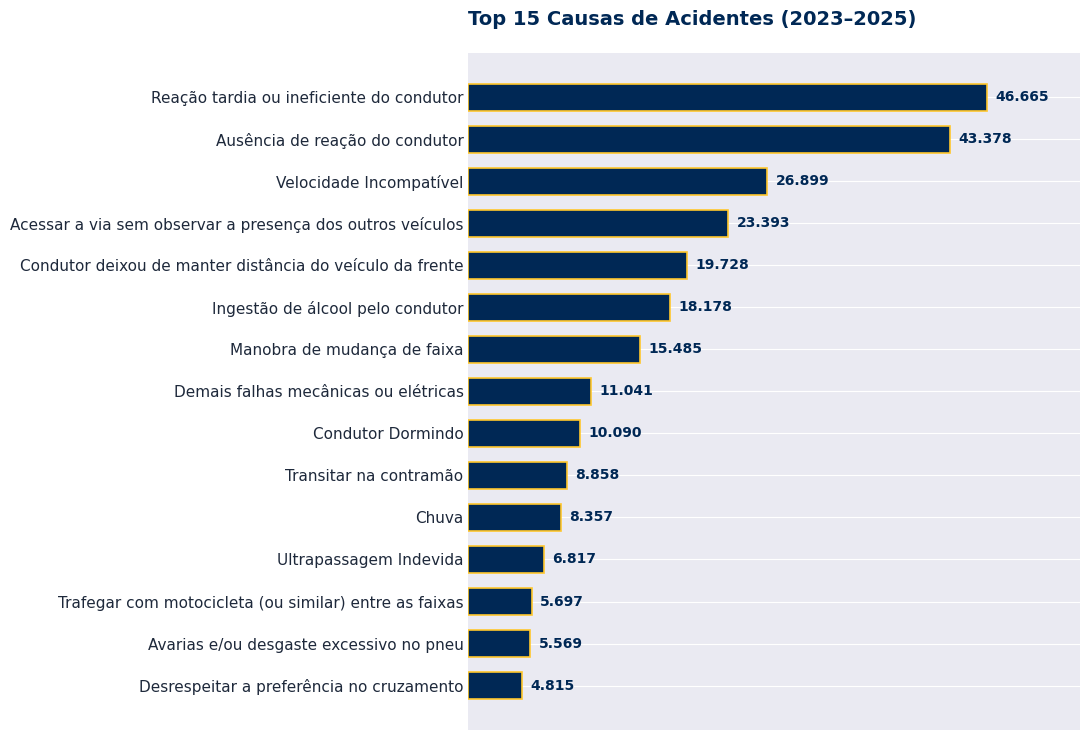

(<Figure size 1100x750 with 1 Axes>,
 <Axes: title={'left': 'Top 15 Causas de Acidentes (2023–2025)'}>)

In [ ]:
causas_por_acidente = df_prf.drop_duplicates(subset=['id', 'causa_acidente'])

top_causas_geral = (
    causas_por_acidente
    .groupby('causa_acidente')
    .size()
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name='quantidade')
    .sort_values('quantidade')  # plot_barh_destaque espera o maior valor por último (topo do gráfico)
)

plot_barh_destaque(
    top_causas_geral, 'causa_acidente', 'quantidade',
    titulo='Top 15 Causas de Acidentes (2023–2025)',
    cores=[AZUL_PRF] * len(top_causas_geral),
    edgecolor=CORES_PRF['amarelo_claro'], linewidth=1.2,
    figsize=(11, 7.5),
)


A análise do gráfico de **Top 15 Causas de Acidentes** revela um forte predomínio de fatores comportamentais e falhas de atenção dos condutores como os principais deflagradores de acidentes nas rodovias federais no período de 2023 a 2025:

1. **Falhas de Percepção e Reação:**
   - **Reação tardia ou ineficiente do condutor:** 46.665 registros (1ª posição).
   - **Ausência de reação do condutor:** 43.378 registros (2ª posição).
   - *Observação:* Juntas, essas duas causas somam **90.043 ocorrências**, destacando a falta de atenção e o tempo de reação inadequado como os maiores vilões do trânsito rodoviário.

2. **Imprudência e Desrespeito às Normas:**
   - **Velocidade Incompatível:** 26.899 registros.
   - **Acessar a via sem observar a presença dos outros veículos:** 23.393 registros.
   - **Condutor deixou de manter distância do veículo da frente:** 19.728 registros.

3. **Fatores Fisiológicos e Subjetivos:**
   - **Ingestão de álcool pelo condutor:** 18.178 registros (6ª posição).
   - **Condutor Dormindo:** 10.090 registros (9ª posição).

4. **Fatores Veiculares e Condições Climáticas:**
   - **Demais falhas mecânicas ou elétricas:** 11.041 registros.
   - **Chuva:** 8.357 registros.
   - **Avarias e/ou desgaste excessivo no pneu:** 5.569 registros.

> **Conclusão:** Políticas públicas de fiscalização, campanhas educativas sobre tempo de reação/distância de segurança e o combate à combinação de álcool e direção (bem como a prevenção da fadiga ao volante) têm potencial de impacto muito superior na redução de acidentes em comparação a intervenções focadas exclusivamente em condições climáticas ou veiculares.

### **14.2 Houve aumento ou redução na quantidade e na gravidade dos acidentes ao longo dos três anos?**

A quantidade por ano já foi calculada na seção 6. Aqui olhamos a **gravidade**: a proporção de acidentes graves/fatais dentro do total de cada ano — não só a contagem bruta, que já cresce/cai junto com o total de acidentes.

In [ ]:
evolucao_gravidade = (
    df_ocorrencias
    .groupby('ano_base')
    .agg(
        total_acidentes=('id', 'count'),
        acidentes_graves_fatais=('grave_ou_fatal', 'sum'),
        acidentes_fatais=('acidente_fatal', 'sum'),
    )
    .assign(
        proporcao_graves_fatais=lambda d: round(d['acidentes_graves_fatais'] / d['total_acidentes'] * 100, 2),
        proporcao_fatais=lambda d: round(d['acidentes_fatais'] / d['total_acidentes'] * 100, 2),
    )
    .reset_index()
)
evolucao_gravidade


,ano_base,total_acidentes,acidentes_graves_fatais,acidentes_fatais,proporcao_graves_fatais,proporcao_fatais
0,2023,67767,19212,4858,28.35,7.17
1,2024,73156,20625,5222,28.19,7.14
2,2025,72529,20493,5210,28.25,7.18


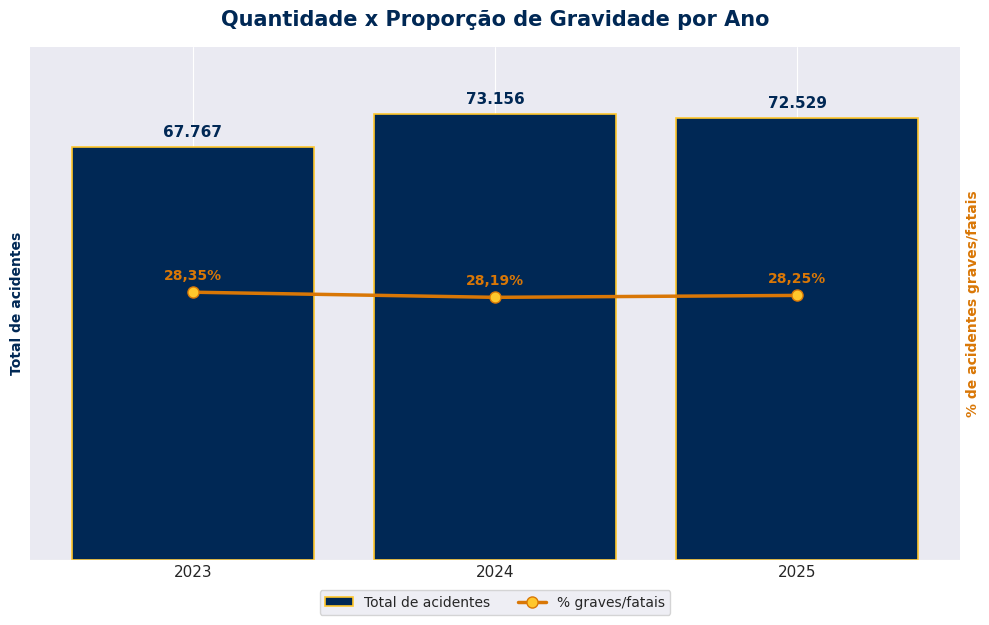

In [ ]:
# Combinação barra + linha em eixos Y independentes: ver nota de storytelling
# na célula de markdown logo abaixo sobre os cuidados com este tipo de gráfico.
fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(
    evolucao_gravidade['ano_base'].astype(str),
    evolucao_gravidade['total_acidentes'],
    color=AZUL_PRF, edgecolor=CORES_PRF['amarelo_claro'], linewidth=1.2,
    label='Total de acidentes',
)
ax1.set_ylabel('Total de acidentes', color=AZUL_PRF, fontweight='bold')
ax1.bar_label(
    bars, labels=[formatar_numero_ptbr(v) for v in evolucao_gravidade['total_acidentes']],
    padding=5, fontweight='bold', color=AZUL_PRF, fontsize=11,
)

ax2 = ax1.twinx()
ax2.plot(
    evolucao_gravidade['ano_base'].astype(str),
    evolucao_gravidade['proporcao_graves_fatais'],
    color=DOURADO_DESTAQUE, marker='o', markersize=8,
    markerfacecolor=CORES_PRF['amarelo_claro'], markeredgecolor=DOURADO_DESTAQUE,
    linewidth=2.5, label='% graves/fatais',
)
ax2.set_ylabel('% de acidentes graves/fatais', color=DOURADO_DESTAQUE, fontweight='bold')

for x, y in zip(evolucao_gravidade['ano_base'].astype(str), evolucao_gravidade['proporcao_graves_fatais']):
    ax2.annotate(
        f'{y:.2f}%'.replace('.', ','), (x, y), textcoords='offset points', xytext=(0, 9),
        ha='center', fontweight='bold', color=DOURADO_DESTAQUE, fontsize=10,
    )

ax1.set_ylim(0, evolucao_gravidade['total_acidentes'].max() * 1.15)
ax2.set_ylim(20, 36)
ax1.yaxis.set_ticks([])
ax2.yaxis.set_ticks([])
ax1.tick_params(axis='x', length=0, labelsize=11)

for spine in ['top', 'left', 'right']:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

plt.title('Quantidade x Proporção de Gravidade por Ano', fontsize=15, fontweight='bold', color=AZUL_PRF, pad=15)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2)
plt.tight_layout()
plt.show()


A análise temporal combinada entre o volume total de acidentes e seus indicadores de severidade revela o comportamento da acidentabilidade nas rodovias federais no triênio:

1. **Volume Total de Acidentes:**
   - **2023:** 67.767 acidentes.
   - **2024:** 73.156 acidentes (**+7,95%** em relação a 2023).
   - **2025:** 72.529 acidentes (**-0,86%** em relação a 2024).
   - *Panorâmica:* Houve um salto relevante de ocorrências de 2023 para 2024, mantendo-se em um patamar elevado em 2025.

2. **Índices de Gravidade e Letalidade:**
   - **Proporção de Graves/Fatais:** 28,35% (2023) $\rightarrow$ 28,19% (2024) $\rightarrow$ 28,25% (2025).
   - **Proporção de Fatais:** 7,17% (2023) $\rightarrow$ 7,14% (2024) $\rightarrow$ 7,18% (2025).
   - *Panorâmica:* Os indicadores de gravidade mantiveram-se **estáveis** em todo o período. A flutuação máxima do indicador de gravidade foi de apenas **0,16 p.p.**

> **Nota Metodológica de Visualização:** O gráfico com eixo Y duplo evidencia o aumento volumétrico em 2024. A oscilação na linha de gravidade deve ser interpretada considerando a escala do eixo Y2 (28,18% a 28,35%), a qual demonstra uma consistência percentual na proporção de vítimas graves e fatais ao longo dos anos.

### **14.3 Quais dias da semana e horários concentram mais acidentes e acidentes graves?**

A seção 8 já mostrou o padrão geral. Aqui isolamos **só os acidentes graves/fatais** para comparar se o horário de pico muda quando se olha apenas para os casos mais sérios.

/tmp/ipykernel_3754/4160773159.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['dia_semana', 'hora'])
/tmp/ipykernel_3754/4160773159.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  rotulos_seletivos = tabela_calor_graves.applymap(


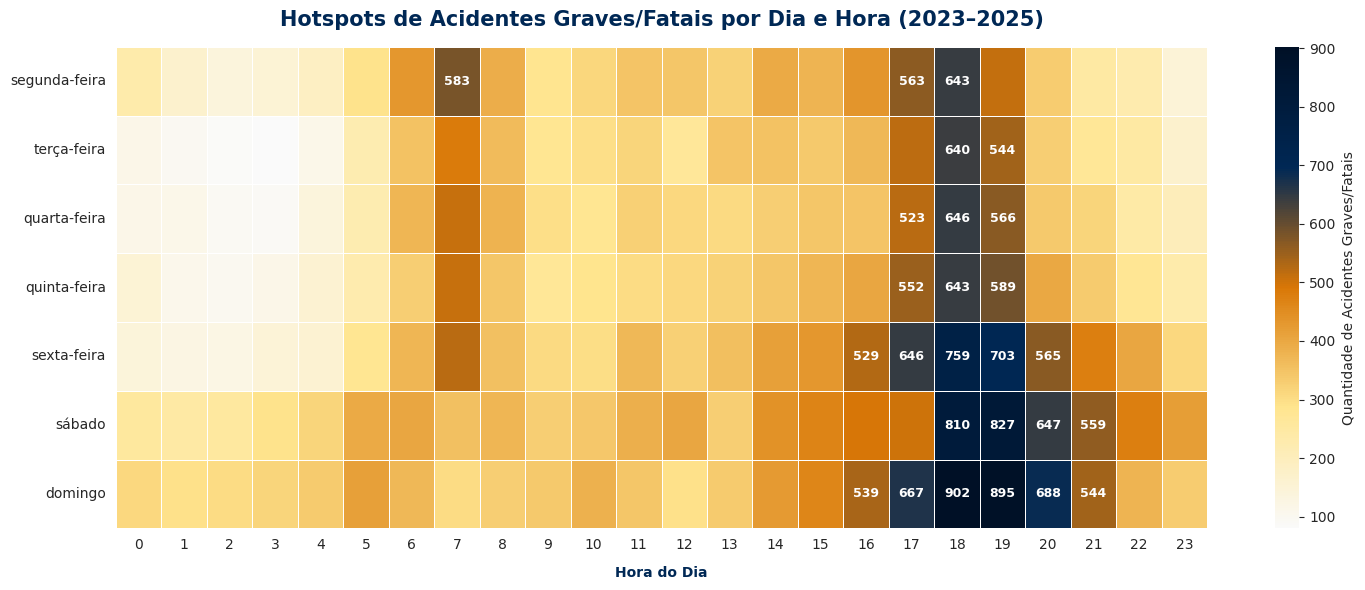

In [ ]:
tabela_calor_graves = (
    df_ocorrencias[df_ocorrencias['grave_ou_fatal'] == 1]
    .assign(dia_semana=lambda d: pd.Categorical(d['dia_semana'], categories=ORDEM_DIAS, ordered=True))
    .groupby(['dia_semana', 'hora'])
    .size()
    .reset_index(name='quantidade')
    .pivot(index='dia_semana', columns='hora', values='quantidade')
)

# Só rotula as células no topo da distribuição (percentil 85) — o objetivo do
# heatmap aqui é destacar hotspots, não funcionar como uma tabela completa.
valores = tabela_calor_graves.values.flatten()
limiar_hotspot = np.percentile(valores[~np.isnan(valores)], 85)

rotulos_seletivos = tabela_calor_graves.applymap(
    lambda val: formatar_numero_ptbr(val) if pd.notnull(val) and val >= limiar_hotspot else ''
)

plt.figure(figsize=(15, 6))
sns.heatmap(
    tabela_calor_graves,
    cmap=CMAP_PRF_HOTSPOT,
    annot=rotulos_seletivos,
    fmt='',
    annot_kws={'size': 9, 'weight': 'bold', 'color': 'white'},
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Quantidade de Acidentes Graves/Fatais'},
)

plt.title('Hotspots de Acidentes Graves/Fatais por Dia e Hora (2023–2025)', fontsize=15, fontweight='bold', color=AZUL_PRF, pad=15)
plt.xlabel('Hora do Dia', fontweight='bold', color=AZUL_PRF, labelpad=10)
plt.ylabel('')
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:
ranking_dia_semana = (
    df_ocorrencias
    .groupby('dia_semana')
    .agg(total=('id', 'count'), graves_fatais=('grave_ou_fatal', 'sum'))
    .assign(proporcao=lambda d: round(d['graves_fatais'] / d['total'] * 100, 2))
    .reindex(ORDEM_DIAS)
)
ranking_dia_semana


,total,graves_fatais,proporcao
dia_semana,,,
segunda-feira,29744,8067,27.12
terça-feira,26715,7201,26.95
quarta-feira,27437,7414,27.02
quinta-feira,27900,7691,27.57
sexta-feira,32882,9128,27.76
sábado,34298,10321,30.09
domingo,34476,10508,30.48


### Distribuição Temporal: Concentração por Dia da Semana e Horário

A análise cruzada entre os dias da semana e as horas do dia revela padrões claros de concentração e gravidade das ocorrências nas rodovias federais (2023–2025):

1. **Efeito Fim de Semana (Volume e Severidade):**
   - **Sábado e Domingo** registram os maiores volumes absolutos de acidentes (~34,3k e ~34,5k, respectivamente) e de acidentes graves/fatais (>10k por dia).
   - **Taxa de Gravidade:** Enquanto nos dias úteis a proporção de acidentes graves/fatais oscila entre **26,95% e 27,76%**, nos finais de semana esse indicador salta para **30,09% no sábado** e **30,48% no domingo**.

2. **Horários de Pico de Gravidade (Hotspots):**
   - **Pico do Fim de Tarde/Noite (17h–20h):** É a faixa mais crítica da malha rodoviária federal em todos os dias da semana, atingindo o ponto máximo às **18h e 19h**. Trata-se da combinação entre queda de visibilidade natural, fadiga e intenso volume de tráfego.
   - **Pico Matutino em Dias Úteis (7h):** Concentração pontual associada ao deslocamento para trabalho e escola.
   - **Madrugada de Lazer (0h–5h no Fim de Semana):** Incremento expressivo na severidade dos acidentes durante a madrugada de sábado e domingo, sugerindo forte correlação com consumo de álcool, excesso de velocidade e cansaço.

> **Direcionamento Estratégico:** A fiscalização ostensiva da PRF e as operações de controle de velocidade/bafômetro devem ter alocação prioritária na faixa das **17h às 21h diariamente**, com reforço especial de patrulhamento nas **madrugadas de sábado e domingo**.

### **14.4 Quais condições meteorológicas estão presentes nos acidentes de maior gravidade?**

In [ ]:
gravidade_clima = (
    df_ocorrencias
    .groupby('condicao_metereologica')
    .agg(total_acidentes=('id', 'count'), graves_fatais=('grave_ou_fatal', 'sum'))
    .assign(proporcao_graves_fatais=lambda d: round(d['graves_fatais'] / d['total_acidentes'] * 100, 2))
    .query('total_acidentes >= 30')  # evita condições raras distorcerem o percentual
    .sort_values('proporcao_graves_fatais', ascending=False)
)
gravidade_clima


/tmp/ipykernel_3754/3577802650.py:6: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query('total_acidentes >= 30')  # evita condições raras distorcerem o percentual


,total_acidentes,graves_fatais,proporcao_graves_fatais
condicao_metereologica,,,
Ignorado,2772,932,33.62
Nevoeiro/Neblina,1794,576,32.11
Céu Claro,135795,39896,29.38
Vento,328,95,28.96
Nublado,32595,9025,27.69
Sol,12058,3260,27.04
Chuva,20558,4888,23.78
Garoa/Chuvisco,7543,1657,21.97


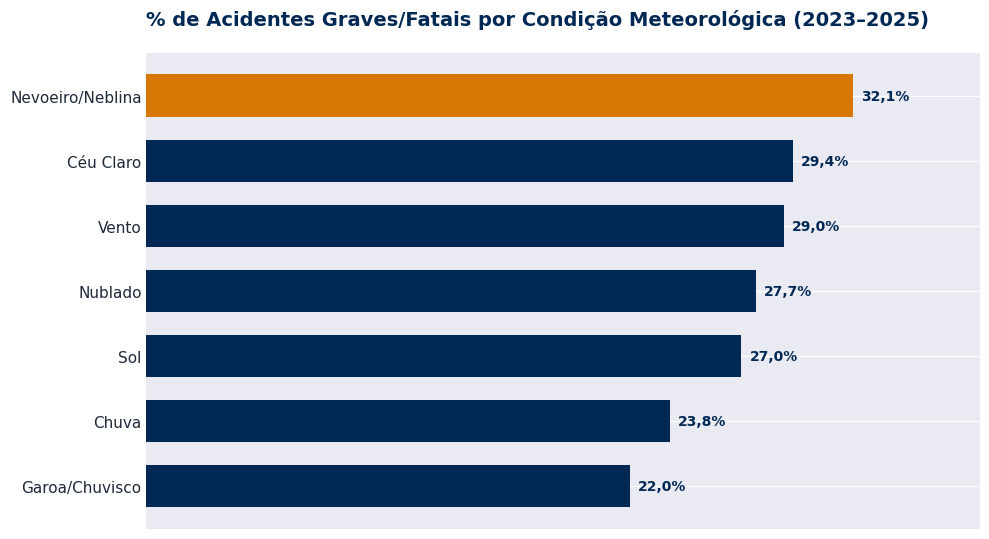

(<Figure size 1000x550 with 1 Axes>,
 <Axes: title={'left': '% de Acidentes Graves/Fatais por Condição Meteorológica (2023–2025)'}>)

In [ ]:
dados_plot = gravidade_clima.drop('Ignorado', errors='ignore').sort_values('proporcao_graves_fatais')

plot_barh_destaque(
    dados_plot.reset_index(), 'condicao_metereologica', 'proporcao_graves_fatais',
    titulo='% de Acidentes Graves/Fatais por Condição Meteorológica (2023–2025)',
    destacar={'Nevoeiro/Neblina'}, casas_rotulo=1, sufixo_rotulo='%',
    figsize=(10, 5.5),
)


### Impacto das Condições Meteorológicas na Gravidade dos Acidentes

A análise da proporção de acidentes graves e fatais por condição climática desmistifica o impacto da chuva e evidencia o perigo de condições que afetam drasticamente a visibilidade:

1. **Nevoeiro/Neblina (Maior Severidade Relativa):**
   - Com **32,11%** de acidentes graves ou fatais, o nevoeiro é a condição climática de maior risco por ocorrência. A perda repentina de visibilidade em velocidade de cruzeiro é o principal fator de agravamento.

2. **O Paradoxo da Pista Seca vs. Chuva:**
   - **Céu Claro (29,38%)** apresenta taxa de gravidade superior à de dias de **Chuva (23,78%)** e **Garoa/Chuvisco (21,97%)**.
   - *Fator Comportamental:* A chuva induz uma postura defensiva (redução da velocidade e maior atenção). Em contrapartida, o tempo bom gera excesso de confiança e velocidades mais elevadas, incrementando a energia do impacto em caso de colisão.

> **Recomendação de Operação:** Painéis de mensagem variável e sinalização preventiva devem priorizar alertas de desaceleração imediata em trechos propensos a **nevoeiro e neblina**, onde a percepção de risco do condutor costuma falhar com mais frequência.

### **14.5 Quais fatores relacionados ao comportamento do condutor aparecem com mais frequência? (álcool, sono, celular, velocidade, ultrapassagem)**

`causa_acidente` é um campo categórico fechado da PRF (76 valores possíveis, ver seção 1). Em vez de buscar por palavra-chave em texto livre — o que arriscaria falsos positivos/negativos —, mapeamos cada um dos 5 comportamentos exatamente às categorias oficiais correspondentes.

In [ ]:
FATORES_CONDUTOR = {
    'Álcool/substâncias psicoativas': ['Ingestão de álcool pelo condutor', 'Ingestão de substâncias psicoativas pelo condutor'],
    'Sono': ['Condutor Dormindo'],
    'Celular': ['Condutor usando celular'],
    'Velocidade incompatível': ['Velocidade Incompatível'],
    'Ultrapassagem indevida': ['Ultrapassagem Indevida'],
}

registros_fator = []
for fator, categorias in FATORES_CONDUTOR.items():
    qtd = causas_por_acidente[causas_por_acidente['causa_acidente'].isin(categorias)]['id'].nunique()
    registros_fator.append({'fator_comportamental': fator, 'qtd_acidentes': qtd})

fatores_condutor_df = pd.DataFrame(registros_fator).sort_values('qtd_acidentes', ascending=False)
total_acidentes_geral = df_ocorrencias['id'].nunique()
fatores_condutor_df['percentual_do_total'] = round(fatores_condutor_df['qtd_acidentes'] / total_acidentes_geral * 100, 2)
fatores_condutor_df

,fator_comportamental,qtd_acidentes,percentual_do_total
3,Velocidade incompatível,26899,12.60
0,Álcool/substâncias psicoativas,18568,8.70
1,Sono,10090,4.73
4,Ultrapassagem indevida,6817,3.19
2,Celular,1922,0.90


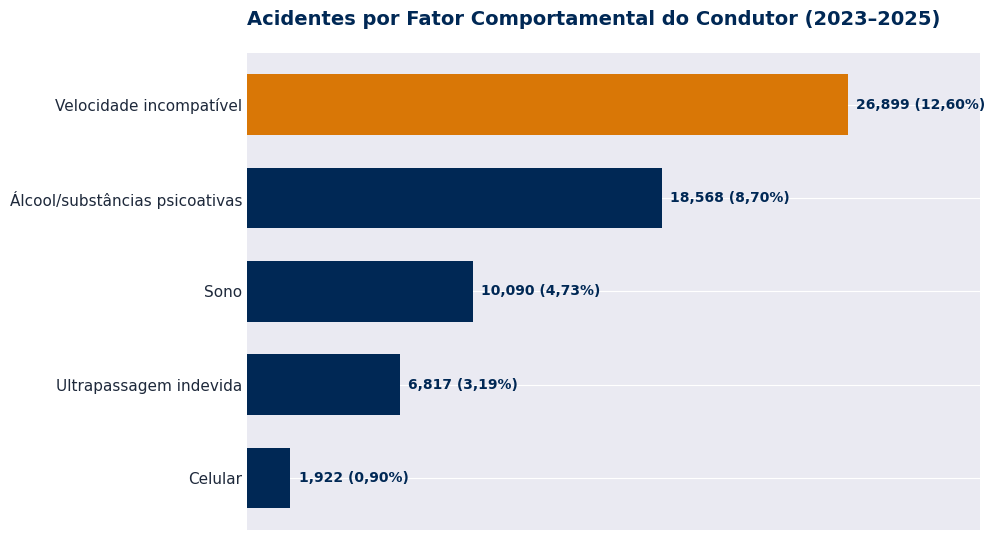

(<Figure size 1000x550 with 1 Axes>,
 <Axes: title={'left': 'Acidentes por Fator Comportamental do Condutor (2023–2025)'}>)

In [ ]:
dados_plot = fatores_condutor_df.sort_values('qtd_acidentes')
rotulos = [
    f'{formatar_numero_ptbr(qtd)} ({pct:.2f}%)'.replace('.', ',')
    for qtd, pct in zip(dados_plot['qtd_acidentes'], dados_plot['percentual_do_total'])
]

plot_barh_destaque(
    dados_plot, 'fator_comportamental', 'qtd_acidentes',
    titulo='Acidentes por Fator Comportamental do Condutor (2023–2025)',
    destacar={'Velocidade incompatível'}, rotulos=rotulos,
    xlim_factor=1.22, figsize=(10, 5.5),
)


### Ranking de Fatores Comportamentais dos Condutores (2023–2025)

A análise dos comportamentos de risco associados aos condutores revela a hierarquia dos principais ofensores à segurança nas rodovias federais:

1. **Velocidade Incompatível (Liderança Isolada):**
   - **26.899 acidentes (12,60%)**, consolidando-se como a infração comportamental mais frequente e de maior impacto na severidade dos sinistros.

2. **Ingestão de Álcool e Substâncias Psicoativas:**
   - **18.568 acidentes (8,70%)**, mantendo a embriaguez ao volante como a segunda maior causa comportamental direta de ocorrências.

3. **Sono e Fadiga:**
   - **10.090 acidentes (4,73%)**, evidenciando a vulnerabilidade ligada a longas jornadas de direção sem descanso adequado.

4. **Ultrapassagem Indevida e Celular:**
   - **Ultrapassagem Indevida:** 6.817 acidentes (3,19%). Embora menor em volume, é o principal vetor de colisões frontais fatais.
   - **Uso do Celular:** 1.922 acidentes (0,90%).

> **Ressalva sobre Subnotificação (Uso de Celular):** A baixa representatividade estatística do uso de celular (0,90%) reflete a complexidade de constatação do uso do aparelho no momento exato da colisão durante o atendimento policial (falta de provas materiais imediatas), consistindo em um viés de subnotificação do banco de dados e não na ausência do risco.

### **14.6 Quais condições da via aparecem com maior frequência nos acidentes?**

`tracado_via` vem como múltiplos atributos concatenados por `;` (ex.: `"Aclive;Curva;Em Obras"`), então tratar cada combinação como uma categoria própria pulveriza a contagem em centenas de combinações raras. Em vez disso, "explodimos" o campo para contar cada característica da via isoladamente.

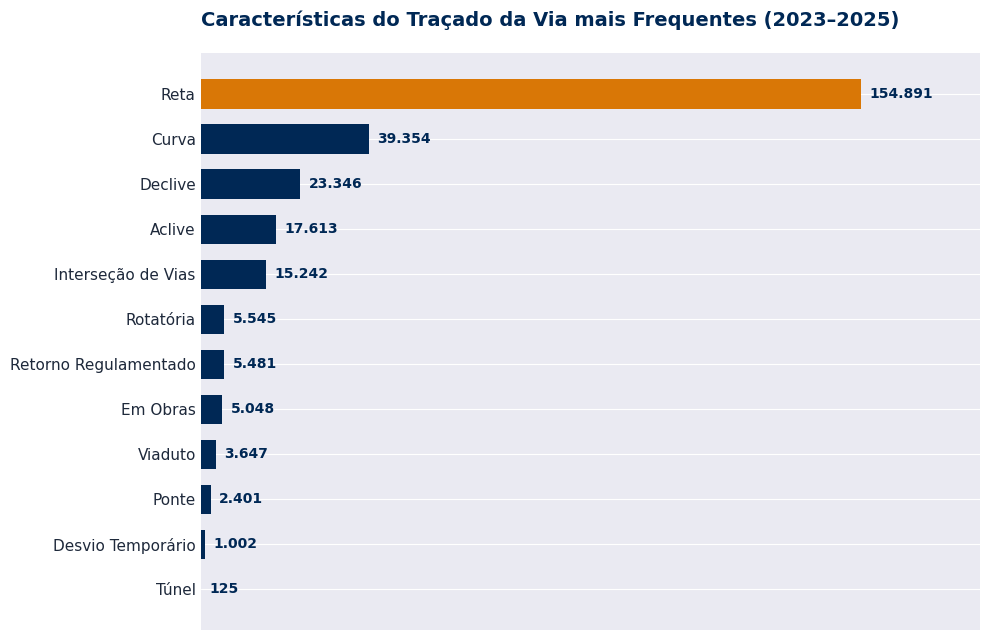

(<Figure size 1000x650 with 1 Axes>,
 <Axes: title={'left': 'Características do Traçado da Via mais Frequentes (2023–2025)'}>)

In [ ]:
# tracado_via vem como múltiplos atributos concatenados por ';' — "explodimos"
# cada valor em uma linha própria antes de contar, em vez de tratar cada
# combinação inteira como uma categoria só (ver explicação na célula acima).
tracado_explodido = (
    df_ocorrencias['tracado_via']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
    .value_counts()
    .reset_index()
)
tracado_explodido.columns = ['caracteristica_via', 'quantidade']
tracado_explodido = tracado_explodido.sort_values('quantidade')

plot_barh_destaque(
    tracado_explodido, 'caracteristica_via', 'quantidade',
    titulo='Características do Traçado da Via mais Frequentes (2023–2025)',
    destacar={'Reta'}, figsize=(10, 6.5),
)


In [ ]:
# Complementando com tipo_pista e uso_solo, que já são categorias únicas (sem necessidade de explode)
for coluna in ['tipo_pista', 'uso_solo']:
    print(f'--- {coluna} ---')
    print(df_ocorrencias[coluna].value_counts())
    print()

--- tipo_pista ---
tipo_pista
Simples     103381
Dupla        89524
Múltipla     20547
Name: count, dtype: int64

--- uso_solo ---
uso_solo
Não    122471
Sim     90981
Name: count, dtype: int64



### Infraestrutura Rodoviária: Traçado, Tipo de Pista e Localização (2023–2025)

A avaliação dos fatores infraestruturais revela onde ocorrem as maiores concentrações de acidentes na malha rodoviária federal:

1. **Traçado da Via (`tracado_via`):**
   - **Reta (Liderança Absoluta):** Presente em mais de **154 mil ocorrências**, o trecho reto é o principal cenário de acidentes. O traçado favorável induz o condutor ao excesso de velocidade e à perda de atenção.
   - **Curva e Relevo:** **Curvas** somam ~39 mil acidentes, enquanto variações de relevo (**Declives e Aclives**) registram ~23 mil e ~17 mil casos, respectivamente, exigindo atenção quanto à frenagem e visibilidade de ultrapassagem.

2. **Tipo de Pista (`tipo_pista`):**
   - **Pista Simples:** **103.381 acidentes (48,4%)**, destacando a vulnerabilidade provocada pela ausência de barreira física central entre os sentidos de tráfego.
   - **Pista Dupla e Múltipla:** Registram **89.524 (41,9%)** e **20.547 (9,6%)** ocorrências, respectivamente.

3. **Uso do Solo (`uso_solo`):**
   - **Trechos Rurais:** Concentram **122.471 acidentes (57,4%)**, prevalecendo sobre os trechos urbanos (**90.981 / 42,6%**).

> **Síntese de Risco:** O perfil típico do acidente em rodovia federal ocorre em **trecho rural**, de **pista simples** e em **linha reta**. Intervenções de engenharia e fiscalização de velocidade em retas rurais de pista simples têm papel crucial na mitigação de colisões de alta energia.

### **14.7 Quais BRs, estados, municípios ou trechos concentram maior número de acidentes graves e fatais?**

A seção 11 já trouxe o ranking de BRs. Aqui completamos com UF, município e "trechos" (BR + faixa de 10 km), que dão uma visão mais fina do que apenas a rodovia inteira.

In [ ]:
print('--- Top UFs por proporção de gravidade ---')
display(ranking_gravidade(df_ocorrencias, 'uf', minimo=50))

print('--- Top municípios por proporção de gravidade ---')
display(ranking_gravidade(df_ocorrencias, ['municipio', 'uf'], minimo=20))


--- Top UFs por proporção de gravidade ---


/tmp/ipykernel_3754/4106709496.py:168: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query(f'total_acidentes >= {minimo}')


,total_acidentes,graves_fatais,proporcao_graves_fatais
uf,,,
MA,3563,1704,47.82
PA,2986,1309,43.84
RR,421,179,42.52
PI,4283,1762,41.14
AL,1961,780,39.78
CE,4165,1566,37.6
PE,9244,3304,35.74
TO,2040,729,35.74
BA,12014,4184,34.83


--- Top municípios por proporção de gravidade ---


/tmp/ipykernel_3754/4106709496.py:168: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query(f'total_acidentes >= {minimo}')


,,total_acidentes,graves_fatais,proporcao_graves_fatais
municipio,uf,,,
ITUPIRANGA,PA,20,17,85.0
SAO DOMINGOS DO ARAGUAIA,PA,21,17,80.95
LAVRAS DA MANGABEIRA,CE,26,21,80.77
CAROLINA,MA,20,16,80.0
DOIS RIACHOS,AL,23,18,78.26
ITINGA DO MARANHAO,MA,21,16,76.19
BOM JESUS DAS SELVAS,MA,25,19,76.0
MARIZOPOLIS,PB,24,18,75.0
AURORA DO PARA,PA,20,15,75.0


In [ ]:
# "Trecho": BR + faixa de 10 km, para localizar pontos críticos dentro de uma mesma rodovia
df_ocorrencias['faixa_km'] = (df_ocorrencias['km'] // 10 * 10).astype('Int64')
df_ocorrencias['trecho'] = df_ocorrencias['br'].astype('Int64').astype(str) + ' km ' + df_ocorrencias['faixa_km'].astype(str) + '-' + (df_ocorrencias['faixa_km'] + 10).astype(str)

print('--- Top trechos (BR + faixa de 10km) por proporção de gravidade ---')
display(ranking_gravidade(df_ocorrencias, 'trecho', minimo=15))

--- Top trechos (BR + faixa de 10km) por proporção de gravidade ---


/tmp/ipykernel_3754/4106709496.py:168: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query(f'total_acidentes >= {minimo}')


,total_acidentes,graves_fatais,proporcao_graves_fatais
trecho,,,
316 km 590-600,24,21,87.5
235 km 100-110,18,15,83.33
424 km 60-70,17,14,82.35
232 km 220-230,15,12,80.0
316 km 350-360,19,15,78.95
402 km 40-50,17,13,76.47
365 km 440-450,17,13,76.47
316 km 600-610,25,19,76.0
242 km 860-870,25,19,76.0


### Análise de Concentração Espacial: UFs, Municípios e Trechos Críticos (2023–2025)

A distribuição geográfica dos acidentes revela uma forte disparidade regional em relação à severidade das ocorrências nas rodovias federais:

1. **Disparidade Regional por UF:**
   - **Liderança em Severidade:** O **Maranhão (MA)** registra a maior taxa de acidentes graves/fatais do país (**47,82%**), seguido por **Pará (43,84%)**, **Roraima (42,52%)** e **Piauí (41,14%)**.
   - *Padrão Geográfico:* Há uma nítida concentração de gravidade nas regiões **Norte e Nordeste**, cujos indicadores ficam muito acima do patamar médio nacional de ~28,25%.

2. **Municípios Críticos (Filtro Mínimo = 20 Acidentes):**
   - Os municípios com maiores taxas de gravidade são cidades de médio/pequeno porte atravessadas por trechos rurais de rodovias de pista simples.
   - Destaque para **Itupiranga/PA (85,0%)**, **São Domingos do Araguaia/PA (80,95%)** e **Lavras da Mangabeira/CE (80,77%)**.

3. **Gargalos Rodoviários em Trechos de 10 km:**
   - **BR-316 (MA/PA):** Abriga o trecho mais severo do país no **km 590–600 (87,5% de gravidade)**, além de múltiplos segmentos na faixa de 76% a 79%.
   - **BR-232 (PE):** Apresenta reincidência sistemática ao longo de sua extensão (km 220–230 com 80,0% e km 330–340 com 75,68%), configurando-se como um corredor prioritário para intervenções de infraestrutura e fiscalização no estado de Pernambuco.

> **Recomendação de Alocação de Recursos:** Operações de fiscalização ostensiva da PRF e melhorias na sinalização/infraestrutura viária devem focar prioritariamente nos corredores da **BR-316** e da **BR-232**, bem como nas interseções urbanas de municípios do interior do MA, PA e CE.

### **14.8 A idade dos condutores apresenta diferenças em relação às causas ou à gravidade dos acidentes?**

Aqui filtramos só as pessoas que dirigiam (`tipo_envolvido == 'Condutor'`) e agrupamos por faixa etária.

In [ ]:
condutores = df_prf[df_prf['tipo_envolvido'] == 'Condutor'].drop_duplicates(subset=['id', 'pesid']).copy()
condutores['faixa_etaria'] = pd.cut(condutores['idade'], bins=BINS_IDADE, labels=LABELS_IDADE, right=False)

print(f'Condutores com idade não informada (-1 ou nula): {(condutores["idade"] <= 0).sum() + condutores["idade"].isna().sum()}')
condutores = condutores[condutores['idade'] > 0]


Condutores com idade não informada (-1 ou nula): 29651


In [ ]:
gravidade_por_faixa = (
    condutores
    .groupby('faixa_etaria', observed=True)['estado_fisico']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename('percentual')
    .reset_index()
    .pivot(index='faixa_etaria', columns='estado_fisico', values='percentual')
)
gravidade_por_faixa

estado_fisico,Ileso,Lesões Graves,Lesões Leves,Óbito
faixa_etaria,,,,
Até 17,13.63,29.39,50.77,6.22
18-24,29.04,16.48,50.97,3.51
25-34,44.13,12.60,40.25,3.03
35-44,53.46,10.71,32.86,2.97
45-59,57.19,10.19,29.21,3.42
60+,56.04,10.10,29.36,4.50


In [ ]:
top3_causas_por_faixa = (
    condutores
    .groupby(['faixa_etaria', 'causa_acidente'], observed=True)
    .size()
    .reset_index(name='quantidade')
    .sort_values(['faixa_etaria', 'quantidade'], ascending=[True, False])
    .groupby('faixa_etaria', observed=True)
    .head(3)
)
top3_causas_por_faixa.style.hide(axis='index')

faixa_etaria,causa_acidente,quantidade
Até 17,Acessar a via sem observar a presença dos outros veículos,217
Até 17,Reação tardia ou ineficiente do condutor,191
Até 17,Ausência de reação do condutor,161
18-24,Reação tardia ou ineficiente do condutor,5713
18-24,Ausência de reação do condutor,4968
18-24,Acessar a via sem observar a presença dos outros veículos,3647
25-34,Reação tardia ou ineficiente do condutor,12931
25-34,Ausência de reação do condutor,11301
25-34,Acessar a via sem observar a presença dos outros veículos,6806
35-44,Reação tardia ou ineficiente do condutor,13603


### Perfil Demográfico: Impacto da Idade na Gravidade e nas Causas dos Acidentes

A análise da distribuição etária dos condutores revela padrões críticos de vulnerabilidade física e comportamentos de risco associados à maturidade ao volante:

1. **Indicadores de Severidade por Faixa Etária:**
   - **Menores de Idade (`Até 17`):** Registram a maior proporção de **óbitos (6,22%)** e de **lesões graves (29,39%)**. A condução não autorizada resulta no cenário de maior risco e gravidade da malha rodoviária.
   - **Condutores Idosos (`60+`):** Apresentam um aumento na taxa de **letalidade (4,50% de óbitos)** quando comparados aos adultos de 25 a 59 anos (~3,1%). A vulnerabilidade física aumenta a mortalidade pós-impacto.
   - **Adultos (25 a 59 anos):** Apresentam os maiores índices de condutores **ilesos (44% a 57%)**, indicando maior experiência na mitigação de acidentes e uso contínuo de equipamentos de segurança.

2. **Causas Dominantes por Estágio de Vida:**
   - **Menores (`Até 17`):** A principal causa é **"Acessar a via sem observar a presença dos outros veículos"**, sinalizando falta de percepção espacial e desrespeito à preferência de passagem na entrada de rodovias.
   - **Adultos (`18 a 59`):** **"Reação tardia ou ineficiente"** e **"Ausência de reação"** dominam amplamente, evidenciando que a desatenção/distração é um padrão transversal em motoristas habilitados.
   - **Sênior (`60+`):** Forte crescimento relativo de **"Acessar a via sem observar..."**, sugerindo perda de acuidade visual e de julgamento de velocidade de aproximação em intersecções.

> **Síntese Institucional:** As ações preventivas devem ser segmentadas: repressão rigorosa à entrega de veículos a menores de idade, campanhas sobre distração e tempo de reação para adultos, e programas de reciclagem com atenção a cruzamentos e preferências de via para condutores da terceira idade.

### **14.9 Quais tipos de veículos estão mais envolvidos nos acidentes registrados?**

Contamos **veículos distintos** (`id` + `id_veiculo`), não linhas de `df_prf` — senão um veículo envolvido em um acidente com 2 causas e 2 tipos seria contado 4 vezes.

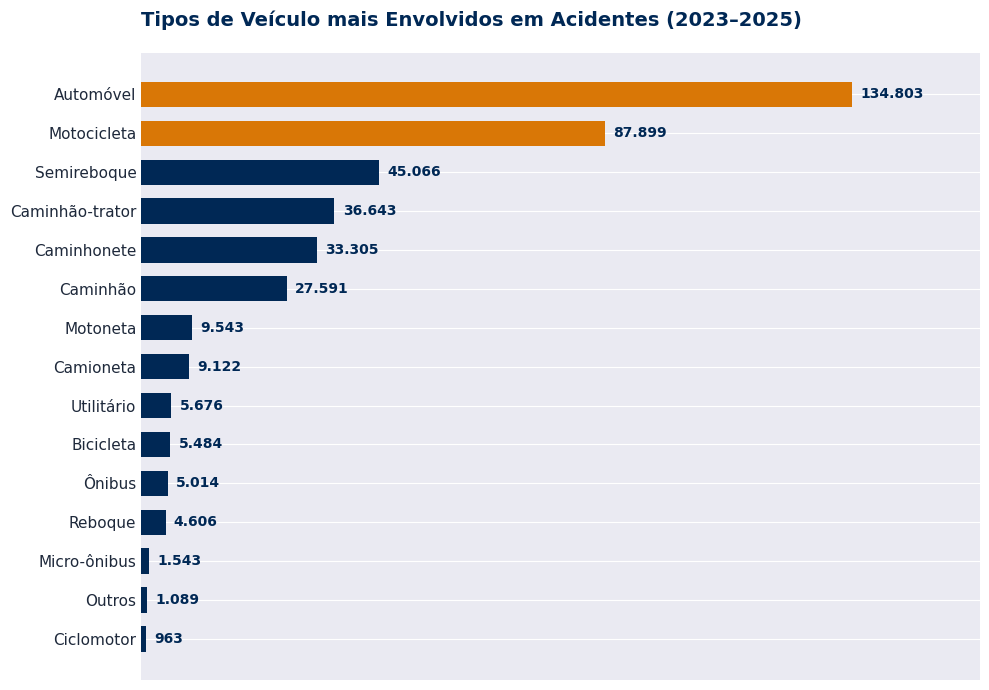

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'left': 'Tipos de Veículo mais Envolvidos em Acidentes (2023–2025)'}>)

In [ ]:
# Veículos distintos (id + id_veiculo) — não linhas de df_prf, senão um mesmo
# veículo com 2 causas e 2 tipos registrados seria contado 4 vezes (ver nota acima).
top_tipos_veiculo = (
    df_prf
    .dropna(subset=['id_veiculo', 'tipo_veiculo'])
    .drop_duplicates(subset=['id', 'id_veiculo'])
    .groupby('tipo_veiculo')
    .size()
    .reset_index(name='quantidade')
    .sort_values('quantidade')
    .tail(15)
)

plot_barh_destaque(
    top_tipos_veiculo, 'tipo_veiculo', 'quantidade',
    titulo='Tipos de Veículo mais Envolvidos em Acidentes (2023–2025)',
    destacar={'Automóvel', 'Motocicleta'}, figsize=(10, 7),
)


### Perfil da Frota Envolvida em Acidentes Rodoviários (2023–2025)

A contagem de veículos únicos envolvidos nas ocorrências revela a composição dos modais com maior sinistralidade na malha federal:

1. **Predomínio da Frota Leve e Duas Rodas:**
   - **Automóvel (135k+ veículos):** É o modal mais presente nos acidentes, acompanhando o volume substancial da frota circulante.
   - **Motocicleta (88k+ veículos):** Consolida-se em 2º lugar, representando uma participação desproporcionalmente alta em relação ao volume de tráfego de duas rodas em rodovias e constituindo o grupo de maior vulnerabilidade física.

2. **Impacto do Transporte Rodoviário de Cargas:**
   - A combinação de **Semireboques (~45k)**, **Caminhões-trator (~36k)** e **Caminhões (~27k)** demonstra que veículos de carga pesada participam de uma parcela expressiva das ocorrências.
   - *Fator de Severidade:* A discrepância de massa entre veículos pesados e demais modais atua como vetor multiplicador de severidade em colisões.

3. **Demais Modais:**
   - **Caminhonetes e Utilitários:** Somam volume significativo (>40k veículos).
   - **Transporte Coletivo (Ônibus/Micro-ônibus):** Apresenta baixo envolvimento absoluto em acidentes, mantendo a característica de transporte massivo com menor índice de ocorrências por passageiro-quilômetro.

> **Direcionamento de Segurança Viária:** Ações de fiscalização e campanhas de conscientização devem ser dualmente focadas: proteção e pilotagem defensiva para **motociclistas** (vulnerabilidade), e rigor no cumprimento de descanso e limites de velocidade para **veículos de carga** (massa/impacto).

### **14.10 Feriados apresentam padrões diferentes dos demais dias (quantidade, horário, causa, gravidade)?**

Não existe uma coluna de feriado nos dados, então construímos uma a partir do calendário oficial de feriados nacionais, usando o pacote `holidays`.

In [ ]:
feriados_br = holidays.Brazil(years=[2023, 2024, 2025])
df_ocorrencias['e_feriado'] = df_ocorrencias['data_inversa'].dt.date.isin(feriados_br)

qtd_dias_feriado = len(set(feriados_br.keys()) & set(df_ocorrencias['data_inversa'].dt.date))
qtd_dias_total = df_ocorrencias['data_inversa'].dt.date.nunique()
print(f'Dias de feriado no período: {qtd_dias_feriado} de {qtd_dias_total} dias cobertos pela base')


Dias de feriado no período: 29 de 1096 dias cobertos pela base


In [ ]:
# Comparação justa: acidentes por DIA (média), não total bruto — já que há muito mais dias
# normais do que feriados no período.
comparacao_feriado = (
    df_ocorrencias
    .groupby('e_feriado')
    .agg(
        total_acidentes=('id', 'count'),
        graves_fatais=('grave_ou_fatal', 'sum'),
        dias_distintos=('data_inversa', lambda s: s.dt.date.nunique()),
    )
    .assign(
        media_acidentes_por_dia=lambda d: round(d['total_acidentes'] / d['dias_distintos'], 2),
        proporcao_graves_fatais=lambda d: round(d['graves_fatais'] / d['total_acidentes'] * 100, 2),
    )
)
comparacao_feriado.index = comparacao_feriado.index.map({True: 'Feriado', False: 'Dia normal'})
comparacao_feriado

,total_acidentes,graves_fatais,dias_distintos,media_acidentes_por_dia,proporcao_graves_fatais
e_feriado,,,,,
Dia normal,207470,58589,1067,194.44,28.24
Feriado,5982,1741,29,206.28,29.1


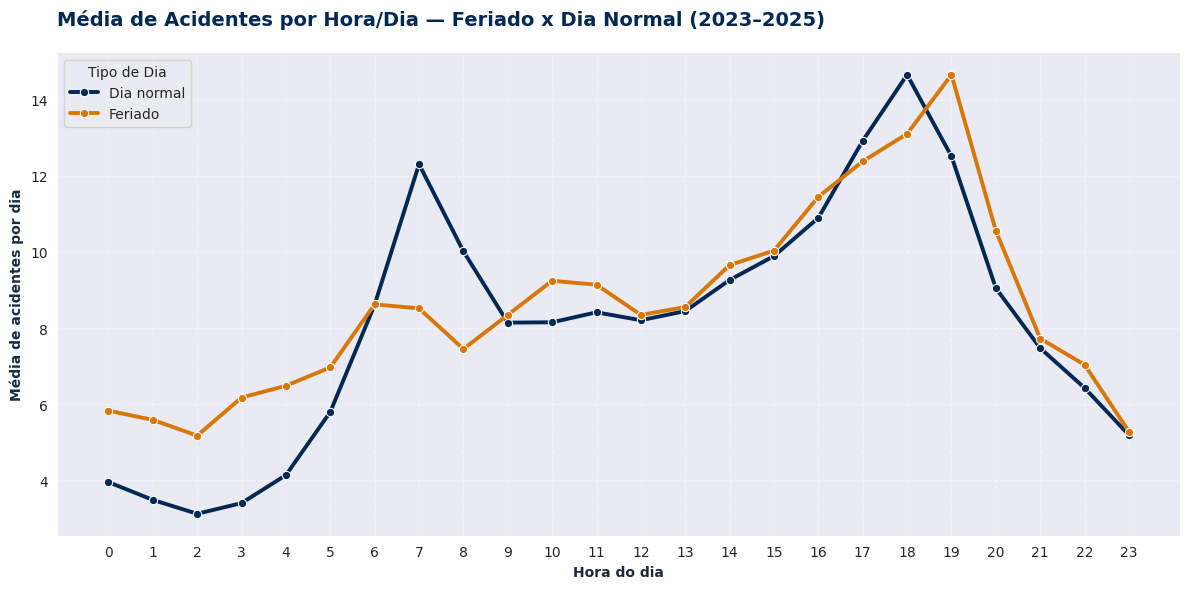

In [ ]:
# pico_feriado: acidentes por hora, separados em feriado x dia normal.
# Reaproveita `comparacao_feriado` (célula anterior) para obter a quantidade
# real de dias de cada categoria, em vez de um número fixo digitado à mão
# (bug da versão anterior: {"Dia normal": 1067, "Feriado": 29} hardcoded,
# que fica errado assim que a base é atualizada com novos dados).
pico_feriado = (
    df_ocorrencias
    .groupby(['hora', 'e_feriado'])
    .size()
    .reset_index(name='quantidade')
)
pico_feriado['e_feriado'] = pico_feriado['e_feriado'].map({True: 'Feriado', False: 'Dia normal'})

dias_por_categoria = comparacao_feriado['dias_distintos'].to_dict()
pico_feriado['dias_totais'] = pico_feriado['e_feriado'].map(dias_por_categoria)
pico_feriado['media_acidentes_hora'] = pico_feriado['quantidade'] / pico_feriado['dias_totais']

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=pico_feriado, x='hora', y='media_acidentes_hora', hue='e_feriado',
    palette={'Feriado': DOURADO_DESTAQUE, 'Dia normal': AZUL_PRF},
    linewidth=2.8, marker='o', markersize=6, ax=ax,
)

plt.title('Média de Acidentes por Hora/Dia — Feriado x Dia Normal (2023–2025)', fontsize=14, fontweight='bold', color=AZUL_PRF, pad=20, loc='left')
plt.xlabel('Hora do dia', fontweight='bold', color=CORES_PRF['cinza_texto'])
plt.ylabel('Média de acidentes por dia', fontweight='bold', color=CORES_PRF['cinza_texto'])

ax.set_xticks(range(0, 24))
ax.grid(True, linestyle='--', alpha=0.4)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.legend(title='Tipo de Dia', title_fontsize='10', fontsize='10', loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


In [ ]:
# Causa mais comum em feriado x dia normal
causas_feriado = causas_por_acidente.merge(
    df_ocorrencias[['id', 'e_feriado']], on='id', how='left'
)

top_causas_feriado = (
    causas_feriado
    .groupby(['e_feriado', 'causa_acidente'])
    .size()
    .reset_index(name='quantidade')
    .sort_values(['e_feriado', 'quantidade'], ascending=[True, False])
    .groupby('e_feriado')
    .head(5)
)
top_causas_feriado['e_feriado'] = top_causas_feriado['e_feriado'].map({True: 'Feriado', False: 'Dia normal'})
top_causas_feriado.style.hide(axis='index')

e_feriado,causa_acidente,quantidade
Dia normal,Reação tardia ou ineficiente do condutor,45368
Dia normal,Ausência de reação do condutor,42102
Dia normal,Velocidade Incompatível,26044
Dia normal,Acessar a via sem observar a presença dos outros veículos,22895
Dia normal,Condutor deixou de manter distância do veículo da frente,19269
Feriado,Reação tardia ou ineficiente do condutor,1297
Feriado,Ausência de reação do condutor,1276
Feriado,Ingestão de álcool pelo condutor,891
Feriado,Velocidade Incompatível,855
Feriado,Acessar a via sem observar a presença dos outros veículos,498


### Padrões Comparativos: Feriados vs. Dias Normais (2023–2025)

A comparação entre os dias normais e os feriados nacionais expõe mudanças significativas no volume, na severidade e no comportamento dos condutores:

1. **Volume e Taxa de Gravidade:**
   - **Média Diária de Acidentes:** Feriados registram uma média de **206,28 acidentes/dia**, superando em **6,1%** a média dos dias normais (**194,44 acidentes/dia**).
   - **Índice de Gravidade:** A proporção de acidentes graves/fatais eleva-se de **28,24% em dias normais para 29,10% nos feriados**.

2. **Ascensão do Álcool como Causa Principal:**
   - **Alteração do Ranking de Causas:** Em dias normais, as causas mais frequentes restringem-se a falhas de atenção e excesso de velocidade. Nos feriados, a **"Ingestão de álcool pelo condutor" salta para a 3ª posição (891 acidentes)**, configurando o maior vetor de risco comportamental diferenciado desse período.

3. **Ajuste Metodológico na Distribuição Horária:**
   - Para neutralizar a disparidade amostral entre a quantidade total de dias normais (1.067) e feriados (29), a análise horária foi padronizada calculando-se a **Média de Acidentes por Hora por Dia** ($\text{Média} = \frac{\text{Soma de Acidentes}}{\text{Total de Dias do Grupo}}$). Essa correção elimina o efeito de esmagamento visual do gráfico e revela a dinâmica real de fluxo e sinistralidade ao longo das 24 horas.

> **Direcionamento Operacional para Operações de Feriado:** O planejamento de operações especiais em feriados prolongados deve intensificar as ações de fiscalização com bafômetro (Operação Lei Seca) e reforçar o patrulhamento preventivo em trechos de turismo e viagens de longa distância.

### **Conclusão final do estudo**

Ao longo do triênio 2023–2025, as rodovias federais registraram **213.452 acidentes** (67.767 em 2023, 73.156 em 2024 e 72.529 em 2025), dos quais **28,26% resultaram em vítimas graves ou fatais** e **7,16% em pelo menos um óbito** — cerca de **17.829 mortes** no período. Reunindo as 10 perguntas da seção 14 com os achados das seções 5 a 13, dá para separar os resultados em três grupos: o que confirmou a intuição inicial, o que surpreendeu, e o que isso sugere como prioridade de ação.

#### O que se confirmou

- **O comportamento do condutor pesa mais do que o ambiente.** As duas causas isoladas mais frequentes são falhas de percepção — *reação tardia ou ineficiente* (46.665) e *ausência de reação* (43.378), somando 90.043 acidentes —, seguidas por *velocidade incompatível* (26.899) e *ingestão de álcool* (18.178/18.568, a depender do recorte). Condições climáticas adversas aparecem muito abaixo disso (chuva: 8.357). O cenário típico do acidente é justamente o mais "confortável" para o condutor relaxar a atenção: reta (55,6%), céu claro (63,6%), pleno dia (55,3%) e pista simples (48,4%).
- **Fim de semana e período noturno concentram risco e gravidade.** Sexta a domingo respondem por 47,6% dos acidentes; sábado e domingo isoladamente já concentram as maiores taxas de gravidade (30,09% e 30,48%, contra 26,95%–27,76% em dias úteis). O intervalo das 17h–20h é o pico absoluto em todos os dias da semana, e a madrugada de fim de semana desponta como janela de risco por fadiga/álcool mesmo com menor volume de tráfego.
- **Pista simples é o principal vetor de gravidade viária.** 33,83% dos acidentes em pista simples são graves/fatais, contra 23,31% em pista dupla — uma chance ~45% maior. Isso já era esperado pela ausência de separação física entre os sentidos, e os dados confirmam com folga.
- **BR-101 e BR-116 dominam o volume, mas não a letalidade.** As duas rodovias concentram 33,2% de todos os acidentes do país, coerente com serem os troncos de maior tráfego — mas, justamente por terem mais trechos duplicados, sua taxa percentual de fatalidade fica abaixo de rodovias de menor volume e pista simples (BR-420: 34,25% fatal; BR-530: 27,85%).
- **Menores de idade têm o pior desfecho comportamental.** Condutores com até 17 anos registram a maior proporção de óbitos (6,22%) e de lesões graves (29,39%) entre todas as faixas etárias — consistente com a hipótese de que direção não autorizada tende a vir acompanhada de menor domínio do veículo e mais risco assumido.

#### O que surpreendeu

- **Céu claro é mais perigoso que chuva.** A taxa de gravidade sob céu claro (29,38%) supera a de dias de chuva (23,78%) e garoa (21,97%). A leitura mais plausível não é que "chover é seguro", mas que o tempo bom reduz a percepção de risco e eleva a velocidade praticada — enquanto a chuva induz uma condução mais defensiva. É um resultado contraintuitivo que vale a pena destacar em qualquer comunicação pública, porque contraria a crença comum de que "acidente é culpa da chuva".
- **Volume e letalidade andam em direções opostas entre regiões.** Sul e Sudeste concentram a maioria absoluta dos acidentes (MG lidera com 13,06% do total), mas têm as menores taxas percentuais de gravidade (20%–25%). Já o Maranhão, com volume bem menor, tem a maior taxa de gravidade do país (>45%) — quase 1 em cada 2 acidentes ali é grave ou fatal. Um raio-x que olhasse só para o total de ocorrências por UF esconderia completamente esse padrão.
- **A gravidade proporcional ficou notavelmente estável, apesar do salto de volume em 2024.** O total de acidentes subiu 7,95% de 2023 para 2024 e se manteve nesse patamar em 2025, mas a proporção de acidentes graves/fatais oscilou menos de 0,2 ponto percentual no triênio (28,35% → 28,19% → 28,25%). Ou seja: mais acidentes aconteceram, mas o "perfil de risco" de cada acidente não piorou — o que sugere que o aumento de 2024 está mais ligado a volume de tráfego do que a uma deterioração geral das condições de segurança viária.
- **Feriados mudam menos o volume do que a composição das causas.** A média diária de acidentes em feriados (206,28) é só 6,1% maior que em dias normais (194,44) — um efeito mais modesto do que se imaginaria para períodos de viagem intensa. O que muda de forma mais marcante é a causa: em feriados, *ingestão de álcool* salta para a 3ª posição no ranking de causas (891 acidentes), um padrão que não aparece com a mesma força em dias normais.
- **Uso do celular aparece com frequência surpreendentemente baixa (0,90%).** Isso quase certamente reflete subnotificação — é difícil para o agente comprovar o uso do aparelho no momento da colisão — e não deve ser lido como "celular é um risco pequeno".

#### Prioridades de ação sugeridas

1. **Infraestrutura de pista simples em corredores críticos.** Duplicação de trechos de alto volume em pista simples, com prioridade para BR-316 (maior volume fatal absoluto: 3.728 acidentes, 569 mortes) e BR-232, que aparecem como gargalos recorrentes tanto no ranking de BRs quanto no de trechos de 10 km.
2. **Fiscalização concentrada em sexta a domingo, das 17h às 21h, mais madrugadas de fim de semana** — é a janela que combina maior volume e maior taxa de gravidade simultaneamente, o alvo com melhor custo-benefício para operações ostensivas e blitz de velocidade/bafômetro.
3. **Campanhas de atenção e distância de segurança, não só de velocidade.** Como reação tardia e ausência de reação juntas superam qualquer outra causa isolada, o maior ganho preventivo provavelmente vem de educação sobre tempo de reação e distância segura — hoje um tema menos visível nas campanhas de trânsito do que velocidade ou álcool.
4. **Atenção diferenciada por faixa etária:** repressão à entrega de veículos a menores de idade (maior letalidade do estudo) e reciclagem de condutores 60+ com foco em cruzamentos e julgamento de velocidade de aproximação (segunda maior taxa de óbito).
5. **Operação Lei Seca reforçada em feriados**, já que é o período em que o álcool sobe de posição no ranking de causas, mesmo com o volume total de acidentes crescendo pouco.

#### Limitações do estudo

Vale registrar três limitações que qualquer leitura destes resultados deve levar em conta: (1) a divergência `veiculos > pessoas` em 11% dos acidentes sugere subnotificação de envolvidos ilesos no boletim de ocorrência, o que pode subestimar levemente o total real de pessoas envolvidas; (2) `idade` e `sexo` têm valores sentinela (`-1` / `inválido`) que precisam ser tratados à parte em qualquer análise demográfica mais fina do que a feita aqui; (3) o estudo é observacional e descritivo — as relações discutidas (ex.: pista simples ↔ gravidade, céu claro ↔ gravidade) são associações consistentes nos dados, não relações causais isoladas de outros fatores (como velocidade da via, VMD ou perfil de tráfego), que exigiriam um modelo estatístico controlado para serem confirmadas.
